# Dataset 2

In [1]:
# data_option = "dataset1"
data_option = "dataset2"
# data_option = "custom"

## Section 1. Initial setup

In [2]:
from speciesot import configure_platform, Config, Data, SpeciesOT

In [3]:
configure_platform()
# configure_platform("gpu")
# configure_platform("cpu")

JAX is configured to use: METAL


### Parameters

In [4]:
if data_option == "custom":
    mask_option = "one_time_point_data"
    threshold = 1.4
    threshold_surer = 2.5
    high_epsilon = 0.01

elif data_option == "dataset2":
    mask_option = "one_time_point_data"
    threshold = 1.4
    threshold_surer = 2.5
    high_epsilon = 0.1

elif data_option == "dataset1":
    mask_option = "time_series_data"
    threshold = 3.0
    threshold_surer = 3.5
    high_epsilon = 0.01

else:
    print("Check data_option.")

In [5]:
iterations = 1000
threshold_eps = 1e-4
low_epsilon = 0.0
threshold_tol = 3.0

In [6]:
if data_option == "dataset1":
    species = ["human", "macaque", "mouse"]
    species_pairs = []  # overwrite later
    species_labels = ["Human", "Macaque", "Mouse"]

elif data_option == "dataset2":
    species = ["human", "chimpanzee", "gorilla", "orangutan", "macaque", "mouse"]
    species_pairs = []  # overwrite later
    species_labels = [
        "Human_iPSC(AK02)",
        "Chimp_iPSC(AK02)",
        "Gorilla_iPSC(AITS)",
        "Orang_iPSC(AITS)",
        "Macaque_ESC(AITS)",
        "Mouse_EpiLC",
    ]

elif data_option == "custom":
    species = ["animal1", "animal2", "animal3"]
    species_pairs = []  # overwrite later
    species_labels = ["Animal1", "Animal2", "Animal3"]

### Set constants

- `mouse_option` : When `data_option = “fujiwara”`, `“mESC#1”` and `“mESC#2”` disappear (`‘drop’`). Only `“drop”` exists.

- `gene_option` : Whether to restrict the analysis to only genes common to all species (`“intersection”`) or not (`“distinct”`)

- `threshold_option` : Whether the threshold for masking in the “preprocessing” process should be automatically adjusted (`"auto"`) or fixed to the value of `threshold_surer` (`"manual"`)

- `metric_option` : Whether the distance matrix between genes is calculated using Euclidean distance (`"euclidean"`) or after weighting the genes (`"weighted"`)

- `dismat_option` : Whether to use principal component analyzed data (`"pca"`) or original data (`"original"`)

- `gwot_option` : Whether to use the smallest hyperparameter epsilon (`"min"`) or only the initial value (`"fixed"`) when performing gromov-wasserstein ot calculations

In [7]:
if data_option == "custom":
    config = Config(
        data_option="custom",
        mouse_option="drop",
        gene_option="distinct",
        threshold_option="auto",
        metric_option="euclidean",
        dismat_option="original",
        gwot_option="fixed",
        mask_option=mask_option,
        iterations=iterations,
        threshold_eps=threshold_eps,
        low_epsilon=low_epsilon,
        high_epsilon=high_epsilon,
        threshold_tol=threshold_tol,
        threshold=threshold,
        threshold_surer=threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )
elif data_option == "dataset2":
    config = Config(
        "dataset2",
        "drop",
        "distinct",
        "auto",
        "euclidean",
        "original",
        "fixed",
        mask_option,
        iterations,
        threshold_eps,
        low_epsilon,
        high_epsilon,
        threshold_tol,
        threshold,
        threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )
elif data_option == "dataset1":
    config = Config(
        "dataset1",
        "drop",
        "distinct",
        "auto",
        "euclidean",
        "original",
        "fixed",
        mask_option,
        iterations,
        threshold_eps,
        low_epsilon,
        high_epsilon,
        threshold_tol,
        threshold,
        threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )

## Section 2. Data preparation

In [8]:
data = Data(config)

### Read CSV file

In [9]:
data = data.read_csv()

human (2895, 32147)
chimpanzee (839, 28521)
gorilla (3938, 29854)
orangutan (3367, 28684)
macaque (3798, 25898)
mouse (1236, 21109)


### Reduce noise and normalize data

In [10]:
data = data.normalization()

# data size after noise reduction and normalization
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(16535), '#non-significant genes': np.int64(15612), '#silent genes': np.int64(0), 'ell': np.int64(65), 'Elapsed time': '0h 0m 8s 335ms', 'solver': 'full'}
human (2895, 32147)
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15569), '#non-significant genes': np.int64(12952), '#silent genes': np.int64(0), 'ell': np.int64(32), 'Elapsed time': '0h 0m 1s 660ms', 'solver': 'full'}
chimpanzee (839, 28521)
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15118), '#non-significant genes': np.int64(14736), '#silent genes': np.int64(0), 'ell': np.int64(66), 'Elapsed time': '0h 0m 11s 494ms', 'solver': 'full'}
gorilla (3938, 29854)
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target

### Limit the genes to be analyzed to transcription factors

In [11]:
data = data.read_tf()

# Number of genes
(1639,)


## Section 3. Each step of the process

In [12]:
spe_ot = SpeciesOT(data)

### Masking and preprocessing


Delete genes where even the maximum value is below the threshold

In [13]:
spe_ot = spe_ot.preprocessing()

# Shape of gene expression data before masking
human (2895, 1492)
chimpanzee (839, 1431)
gorilla (3938, 1383)
orangutan (3367, 1449)
macaque (3798, 1443)
mouse (1236, 988)
# Shape of adata after removing columns (gene) where even the maximum value is below the threshold
human (2895, 1144)
chimpanzee (839, 1083)
gorilla (3938, 1026)
orangutan (3367, 1107)
macaque (3798, 1129)
mouse (1236, 633)
# Number of genes for which the maximum expression value is greater than a threshold value
human (1144,)
chimpanzee (1083,)
gorilla (1026,)
orangutan (1107,)
macaque (1129,)
mouse (633,)


### Calculate transcriptome distribution

In [14]:
spe_ot = spe_ot.calculate_gene_distance_matrix()

### Plot gene-wise distance matrix

human (1144, 1144)


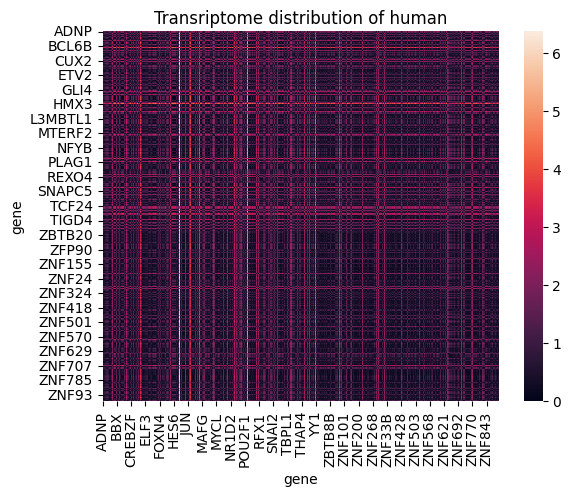

chimpanzee (1083, 1083)


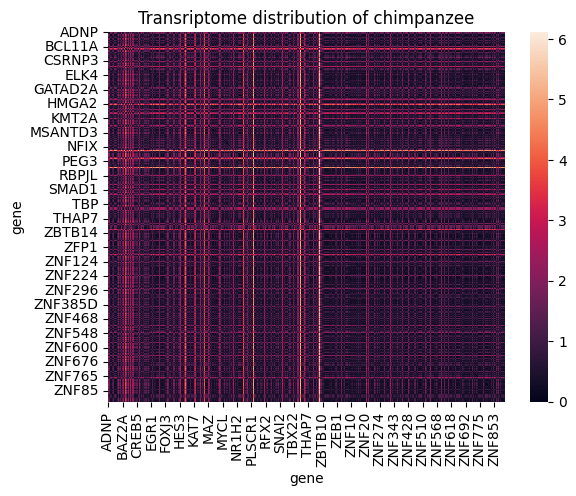

gorilla (1026, 1026)


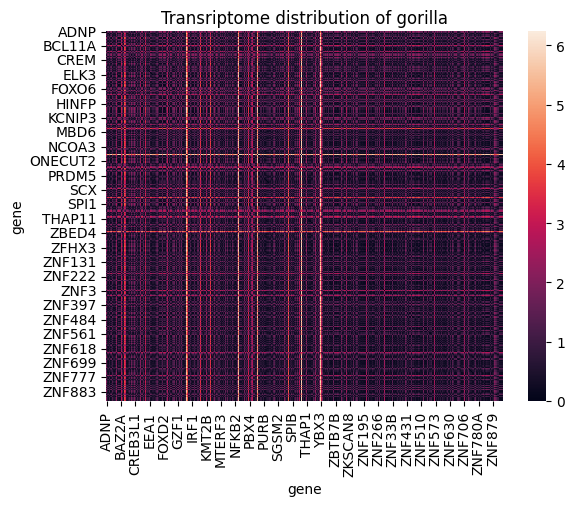

orangutan (1107, 1107)


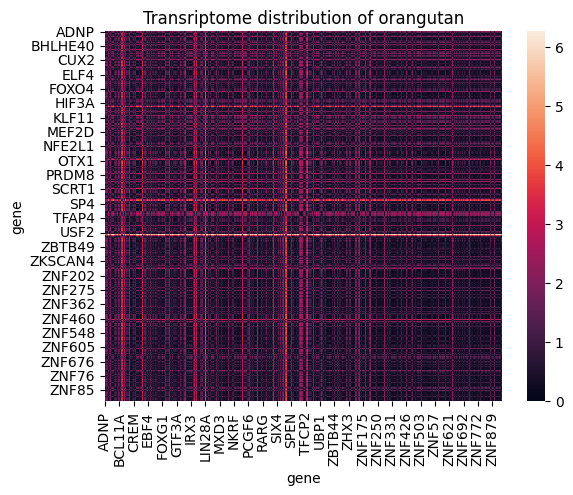

macaque (1129, 1129)


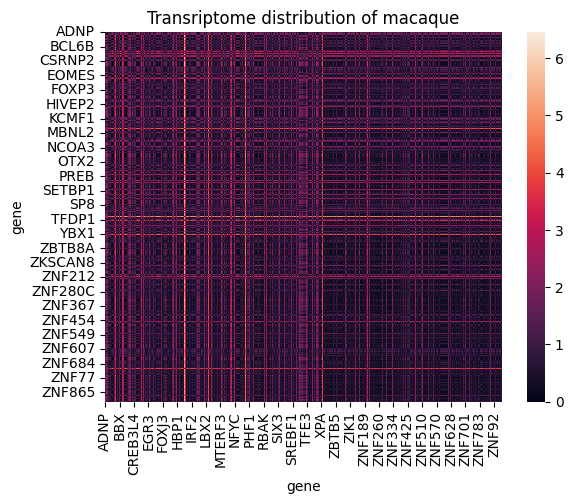

mouse (633, 633)


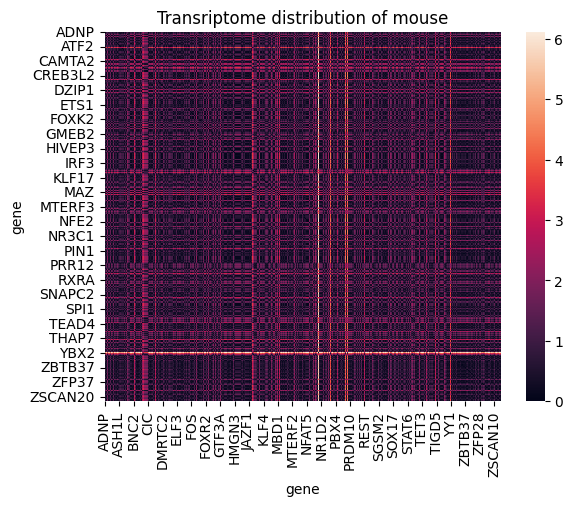

Check mean of gene distance matrices
human 0.9999999999999998
chimpanzee 1.0
gorilla 1.0000000000000007
orangutan 0.9999999999999997
macaque 0.9999999999999998
mouse 0.9999999999999997
Check variance of gene distance matrices
human 0.6469883989099203
chimpanzee 0.6212417325078046
gorilla 0.7518353187859766
orangutan 0.6814894305931531
macaque 0.7238282546733162
mouse 0.6965826802933067


In [15]:
spe_ot.check_gene_distance_matrix()

### Gromov-Wasserstein Optimal Transport
Calculate the optimal transport plan by solving the Entropy-regulalized GW problem

In [16]:
spe_ot = spe_ot.gromov_wasserstein_ot()

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M3 Max

systemMemory: 128.00 GB
maxCacheSize: 48.00 GB



W0000 00:00:1760617536.525577 2876364 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1760617536.536534 2876364 service.cc:145] XLA service 0x33e06d550 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760617536.536542 2876364 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1760617536.537704 2876364 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1760617536.537717 2876364 mps_client.cc:384] XLA backend will use up to 103078739968 bytes on device 0 for SimpleAllocator.


epsilon = 0.1000000 converged


### Calculate normalized OTP (gene-to-gene correspondence rate)

In [17]:
spe_ot = spe_ot.normalize_otp()

### Transcriptomic discrepancy

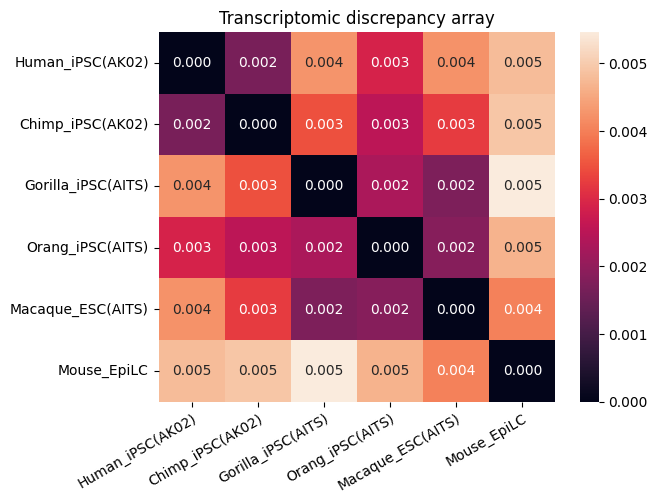

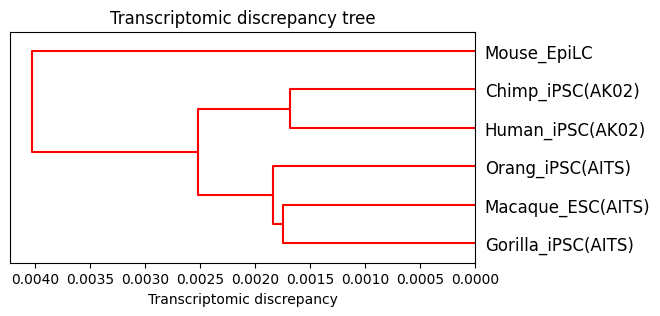

In [18]:
spe_ot.plot_transcriptomic_discrepancy()

### Gene-to-gene Corespondence

In [19]:
if spe_ot.data_option == "dataset1":
    target_genes = ["GATA3", "GATA2", "EOMES", "SOX17", "PRDM1", "TFAP2C"]
    target_species_pairs = "human_mouse"
    # target_species_pairs = "mouse_human"
elif spe_ot.data_option == "dataset2":
    target_genes = ["GATA3", "POU5F1", "SOX2"]
    target_species_pairs = "human_chimpanzee"
elif spe_ot.data_option == "custom":
    target_genes = ["GATA3", "GATA2", "EOMES"]
    target_species_pairs = "animal1_animal2"

top_n = 10

In [20]:
primate_gene_notation = ["all_capital_italic"] * len(spe_ot.species)
spe_gene_dict = dict(zip(spe_ot.species, primate_gene_notation))

# Reflects differences in genetic notation between primates and other species
if spe_ot.data_option == "dataset2":
    spe_gene_dict["mouse"] = "capitalized_italic"
elif spe_ot.data_option == "dataset1":
    spe_gene_dict["Ms"] = "capitalized_italic"

### Summarize results in Dashboard

In [21]:
spe_ot.dashboard(target_species_pairs, target_genes, top_n)

Human_iPSC(AK02) -> Chimp_iPSC(AK02): GATA3Human_iPSC(AK02) -> Chimp_iPSC(AK02): POU5F1Human_iPSC(AK02) -> Chimp_iPSC(AK02): SOX2
shape: (10, 3)                      shape: (10, 3)                      shape: (10, 3)                      
┌───────┬─────────┬────────┐        ┌───────┬────────┬─────────┐        ┌───────┬────────┬─────────┐        
│ index ┆ Gene    ┆ Value  │        │ index ┆ Gene   ┆ Value   │        │ index ┆ Gene   ┆ Value   │        
│ ---   ┆ ---     ┆ ---    │        │ ---   ┆ ---    ┆ ---     │        │ ---   ┆ ---    ┆ ---     │        
│ u32   ┆ str     ┆ str    │        │ u32   ┆ str    ┆ str     │        │ u32   ┆ str    ┆ str     │        
╞═══════╪═════════╪════════╡        ╞═══════╪════════╪═════════╡        ╞═══════╪════════╪═════════╡        
│ 1     ┆ SIM2    ┆ 0.5713 │        │ 1     ┆ POU5F1 ┆ 64.0952 │        │ 1     ┆ NME2   ┆ 53.9915 │        
│ 2     ┆ MSANTD1 ┆ 0.5703 │        │ 2     ┆ TERF1  ┆ 19.5391 │        │ 2     ┆ POU5F1 ┆ 28.1292 │       

### Confirmation of expression levels of target genes and corresponding genes

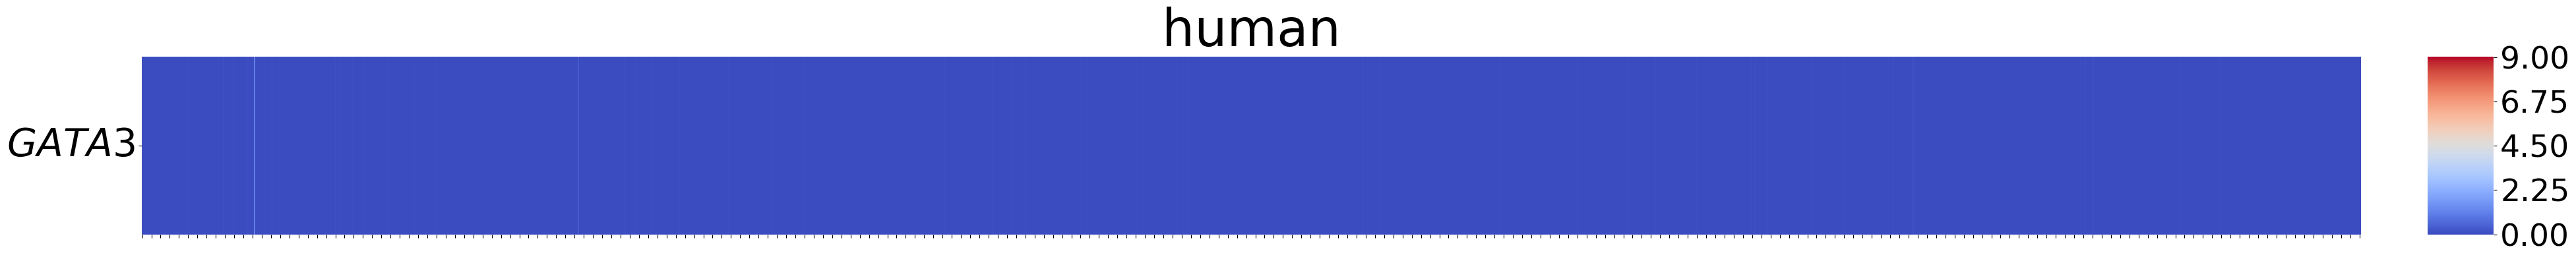

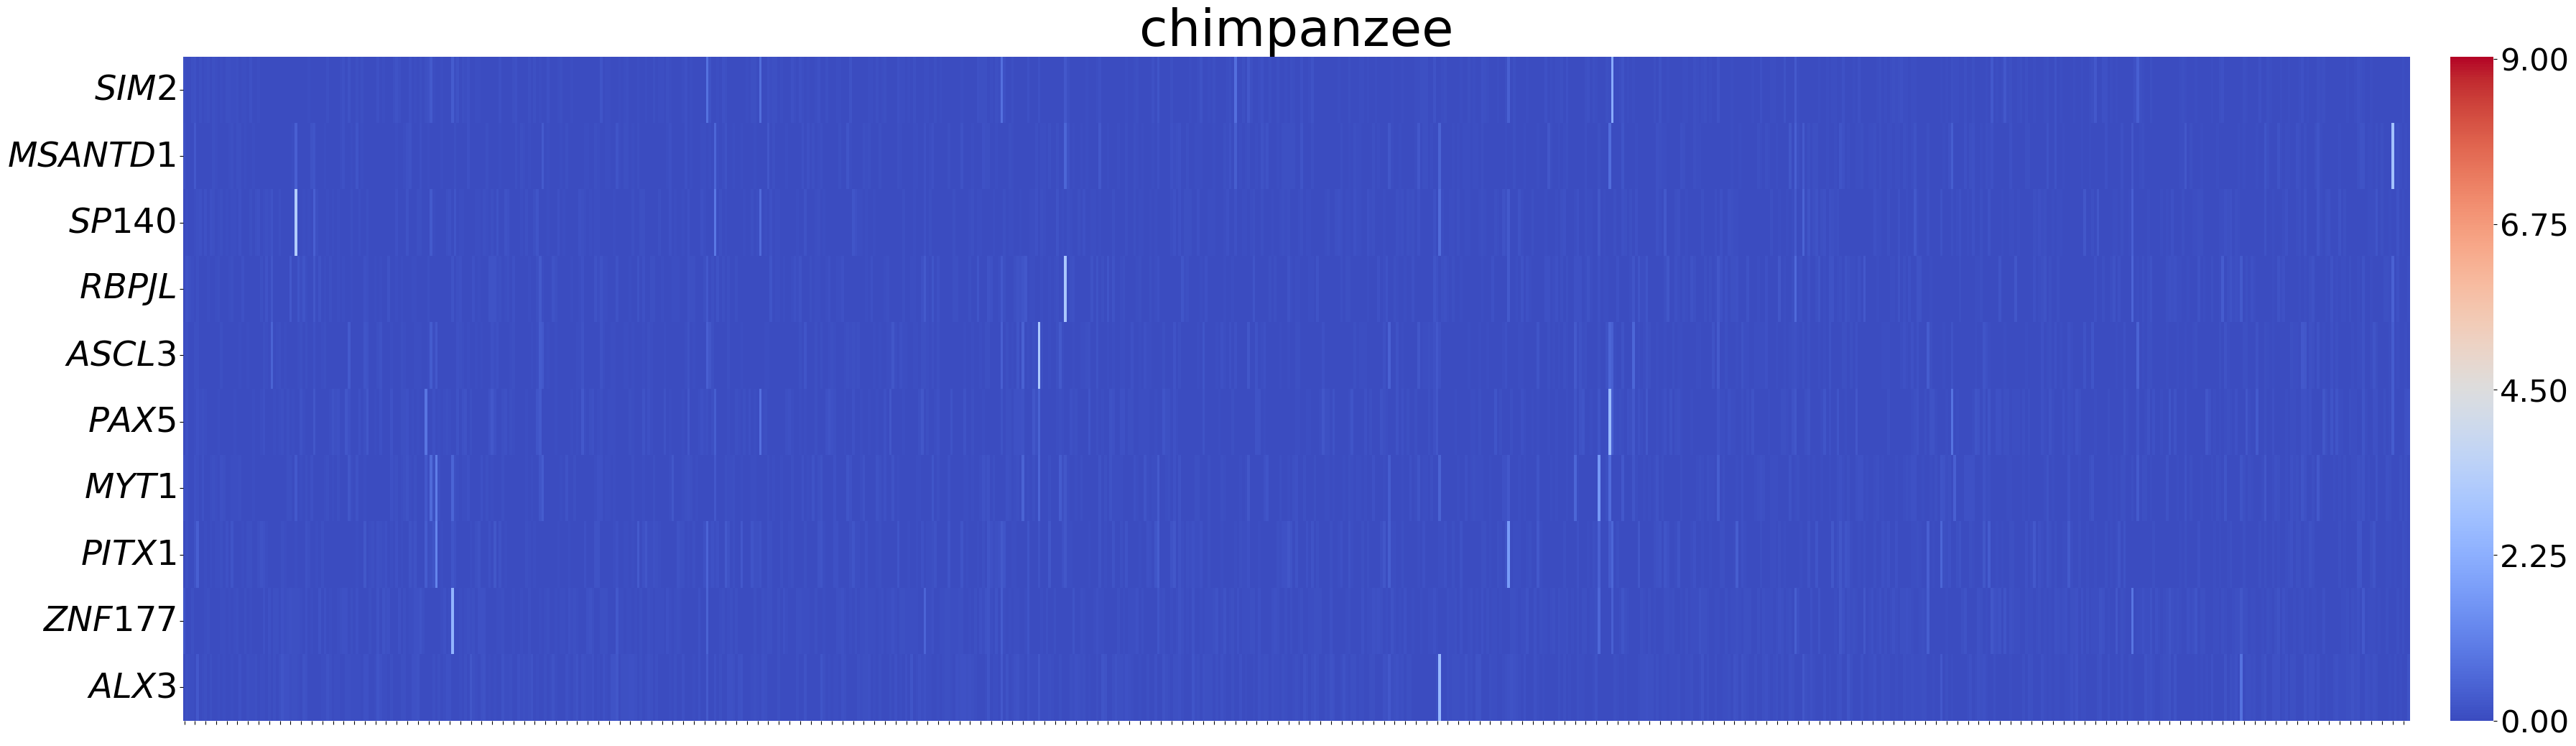

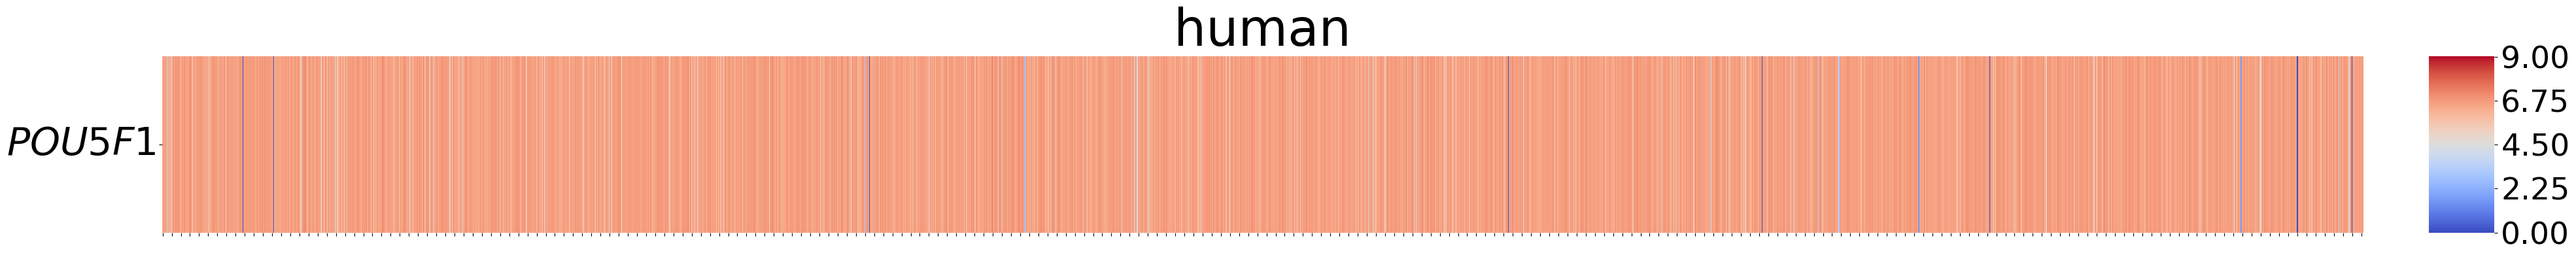

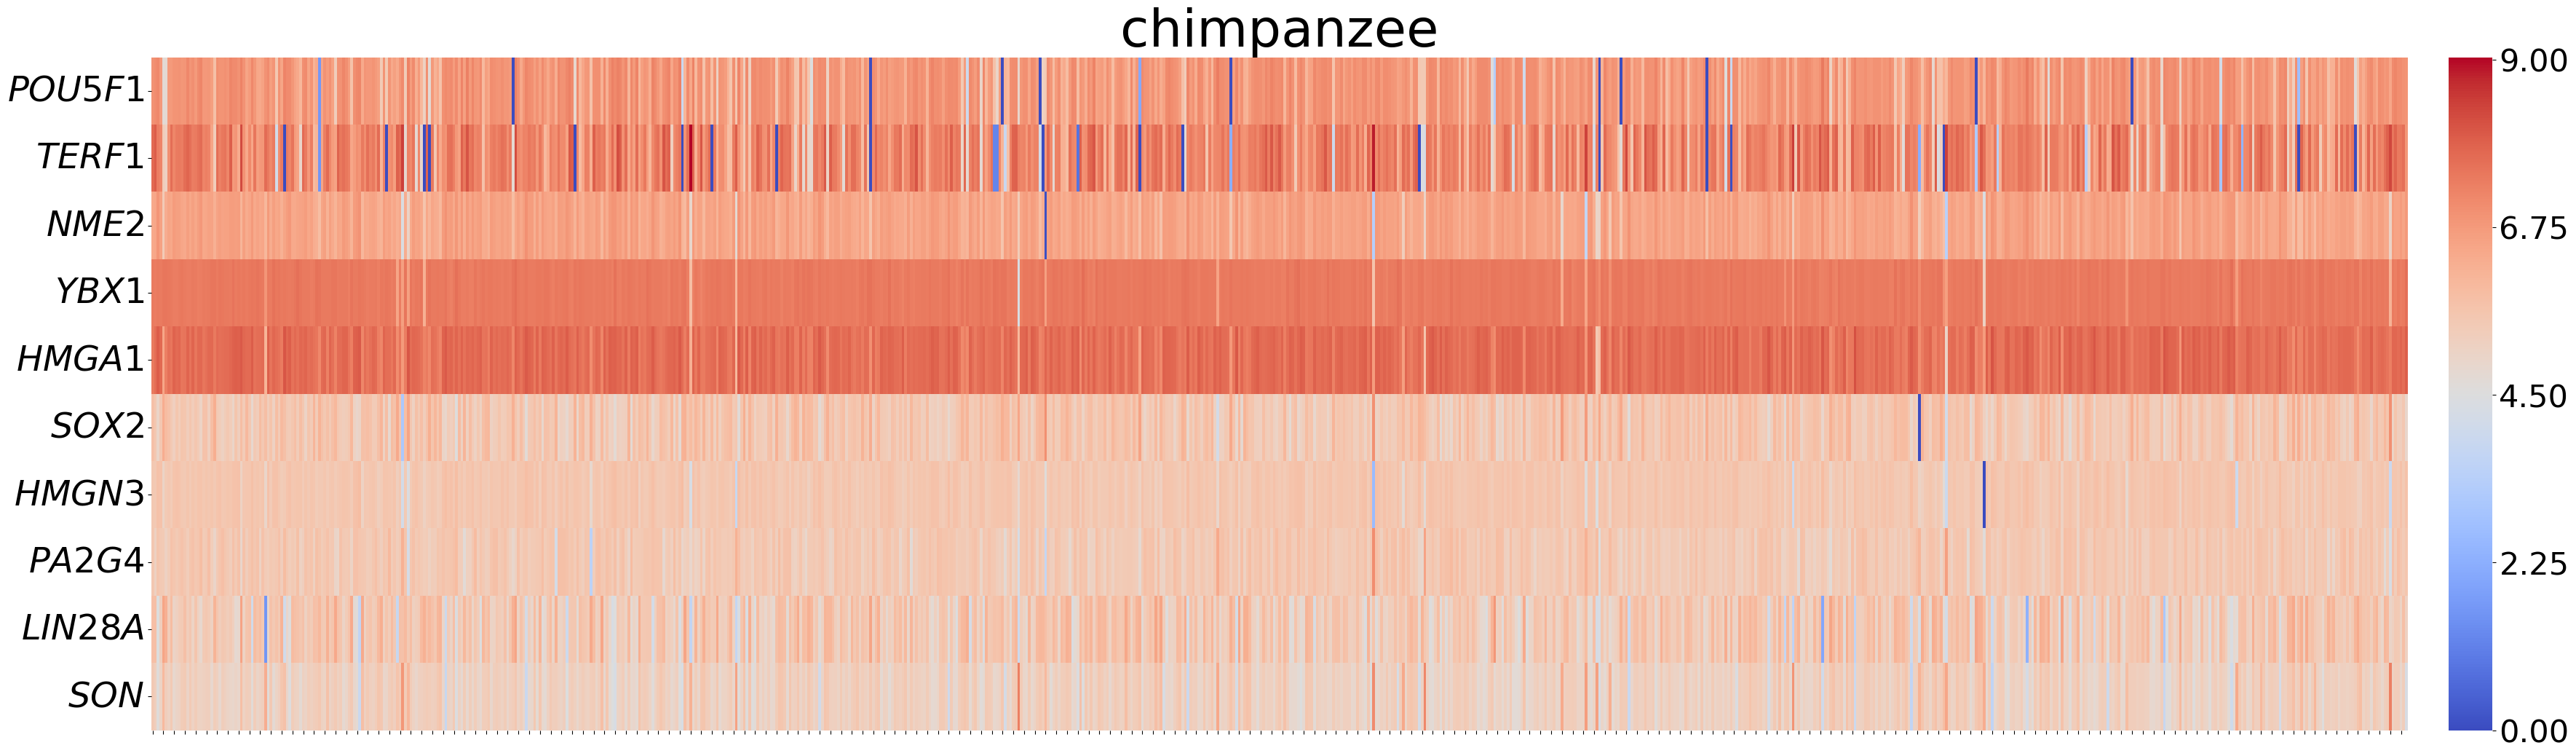

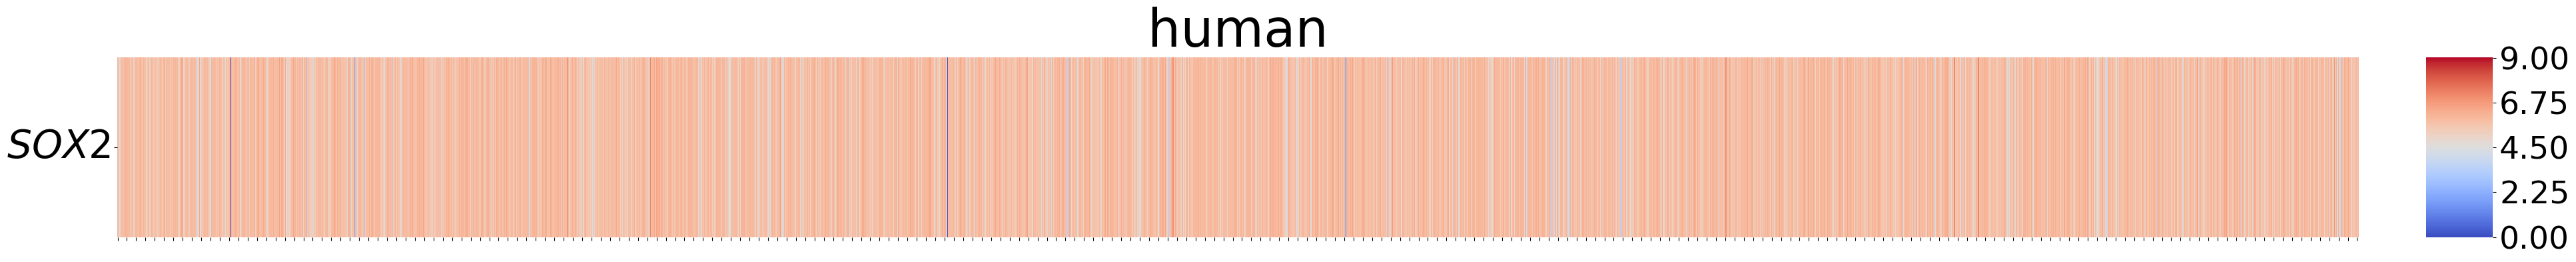

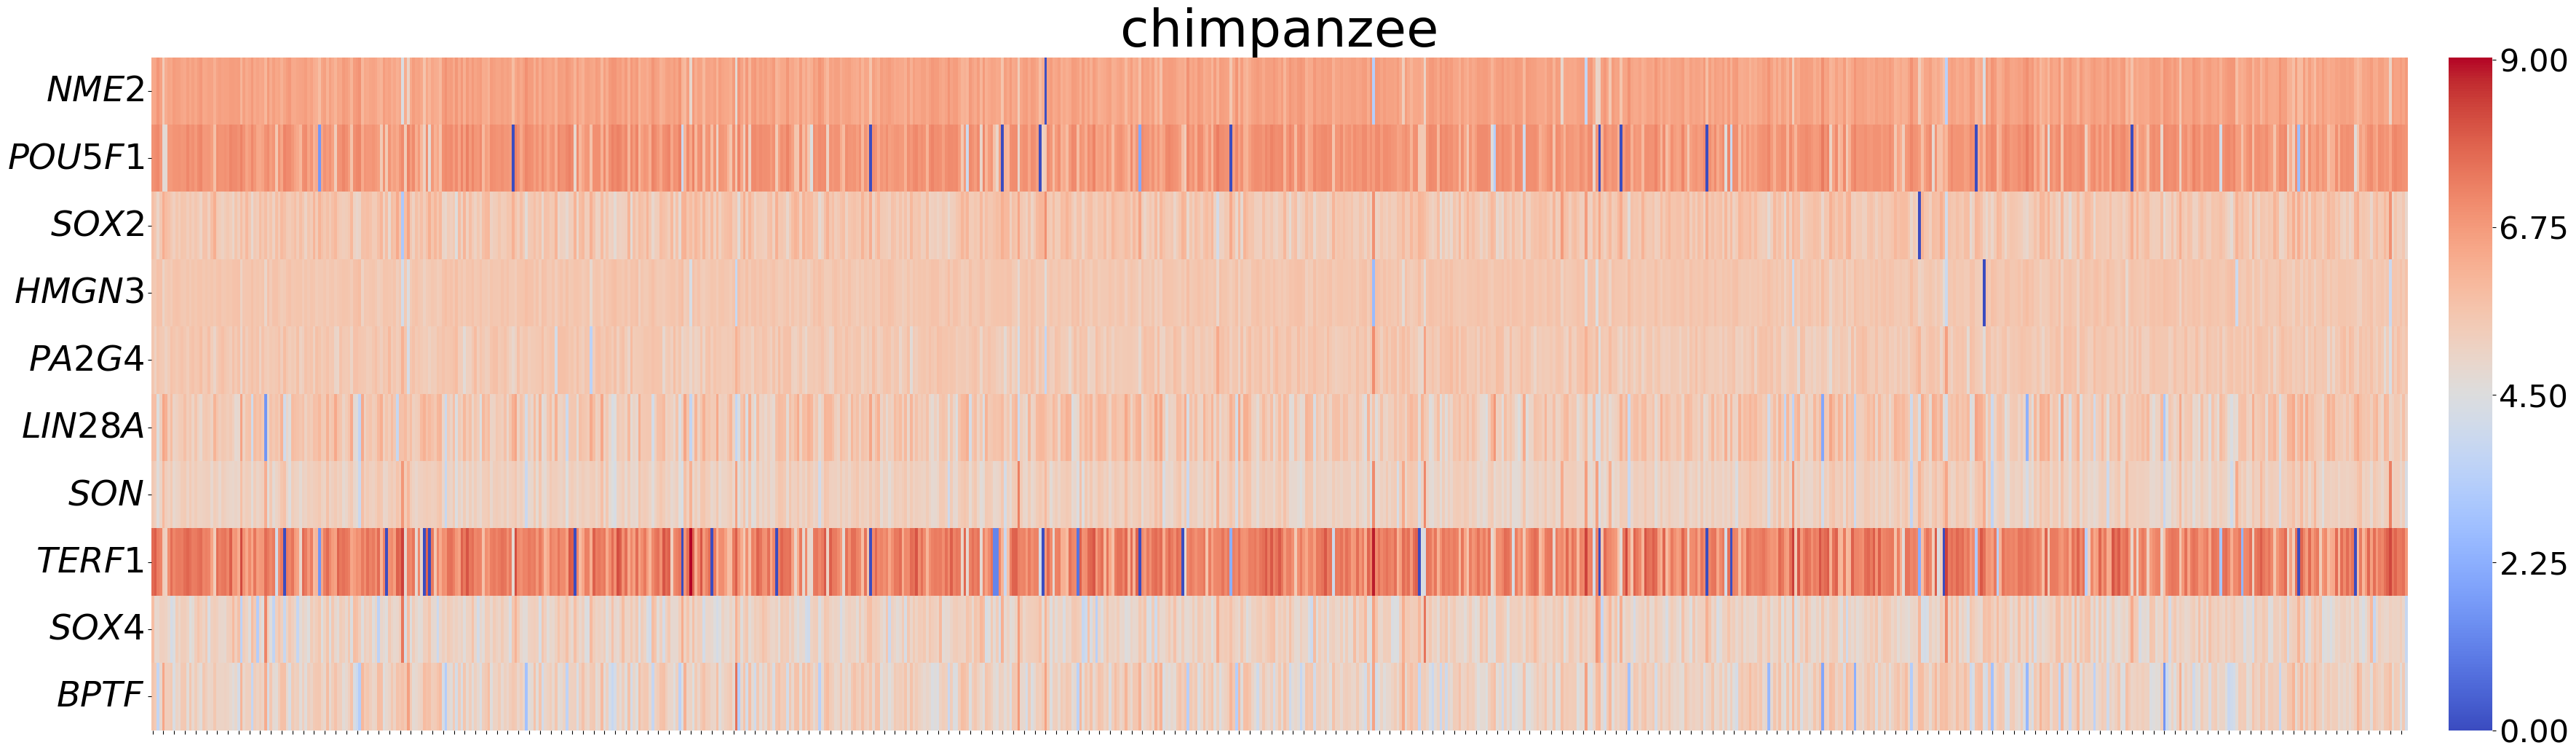

In [22]:
if spe_ot.data_option == "dataset1":
    spe_ot.corresponding_gene_expressions_separated_heatmap(target_species_pairs, spe_gene_dict, target_genes, top_n, fujiwara_opt=True)
else:
    spe_ot.corresponding_gene_expressions_separated_heatmap(target_species_pairs, spe_gene_dict, target_genes, top_n)

## Section 4. Visualization

### Check gene expression level

In [23]:
if data.data_option == "custom":
    spe = "animal1"
    thr = 12.1
    genes = ["POU5F1", "SOX2"]
elif data.data_option == "dataset2":
    spe = "mouse"
    thr = 4.5
    if spe == "human":
        genes = ["POU5F1", "SOX2"]
    else:
        genes = ["ZXDC", "ZZZ3"]
elif data.data_option == "dataset1":
    spe = "Hs"
    thr = 12.1
    genes = ["POU5F1", "SOX2"]

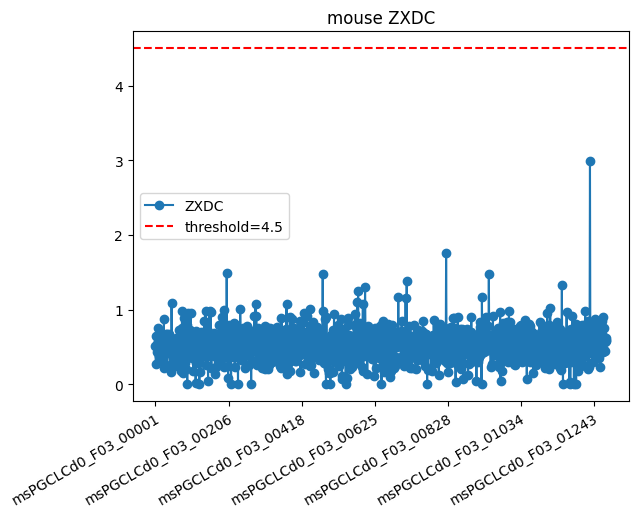

In [24]:
data.check_gene_exp(spe, genes[0], thr)

In [25]:
data.plot_read()

# Shape of Polars DataFrame with cell names added to the beginning of gene expression data
human (2895, 32148)
chimpanzee (839, 28522)
gorilla (3938, 29855)
orangutan (3367, 28685)
macaque (3798, 25899)
mouse (1236, 21110)
human Shape of the gene expression matrix (2895, 32147)
# Showing the first 5 rows (cells) and first 6 columns (genes) of the expression matrix for 'human'
gene            A1BG  A1BG-AS1      A1CF       A2M   A2M-AS1     A2ML1
human_0001  0.070151  0.780990  0.000847  0.060216  0.204614  0.067162
human_0002  0.012530  0.851910  0.000849  0.050376  0.205129  0.159543
human_0003  0.039508  0.771672  0.000843  0.027948  0.204929  0.183951
human_0004  0.055093  0.845176  0.000863  0.000000  0.204705  0.065437
human_0006  0.054223  0.798116  0.000844  0.035138  0.204725  0.124892
chimpanzee Shape of the gene expression matrix (839, 28521)
# Showing the first 5 rows (cells) and first 6 columns (genes) of the expression matrix for 'chimpanzee'
gene            A1BG  A1BG-AS1

#### Plot the distribution of gene expression levels

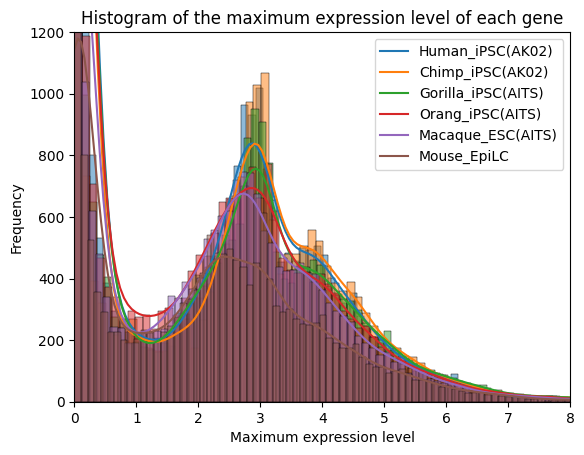

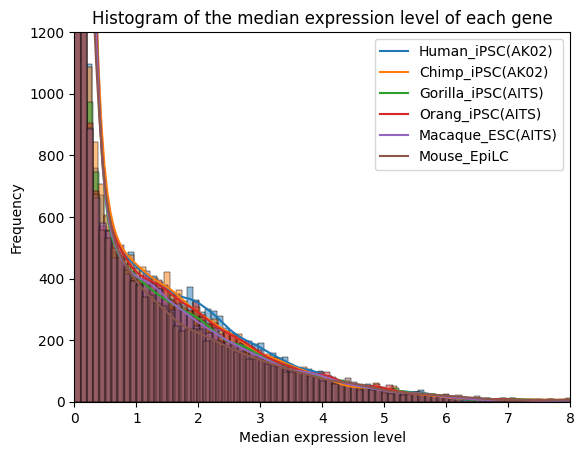

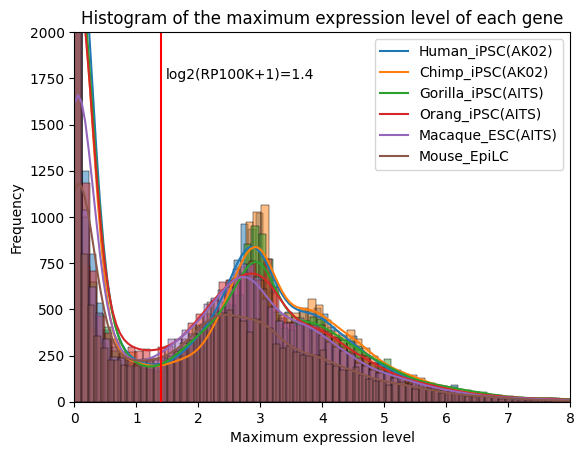

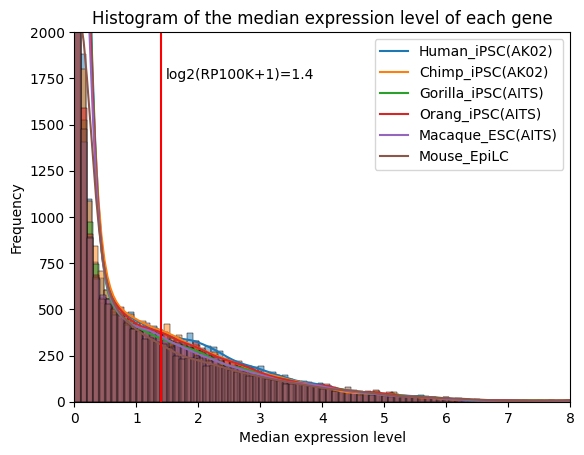

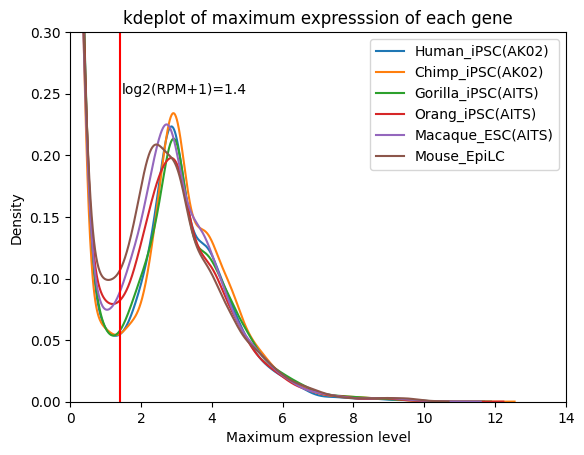

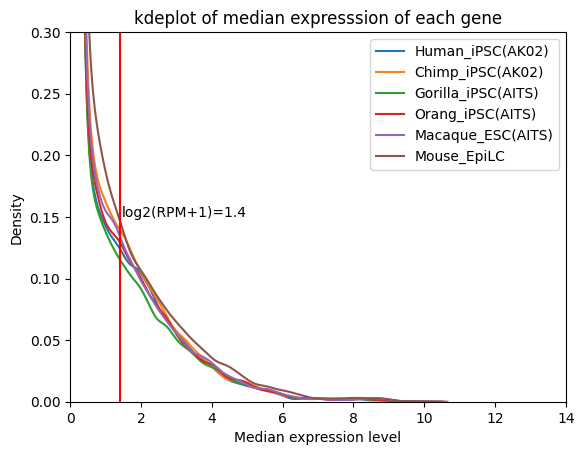

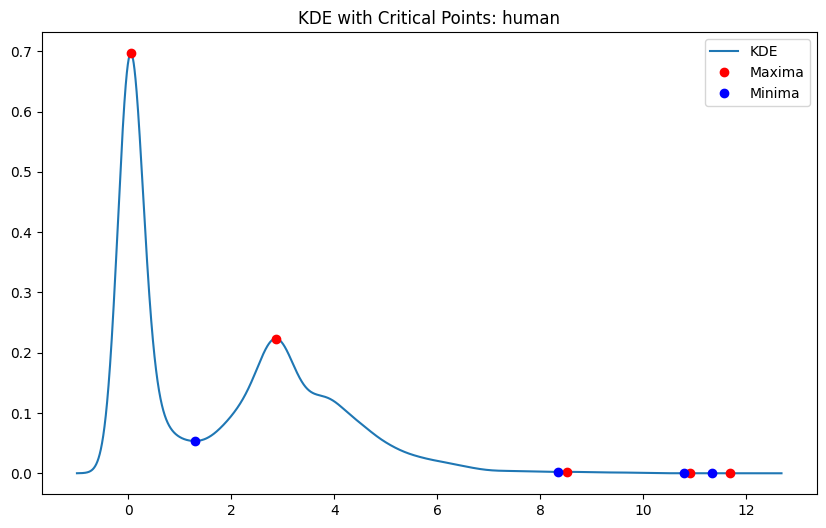

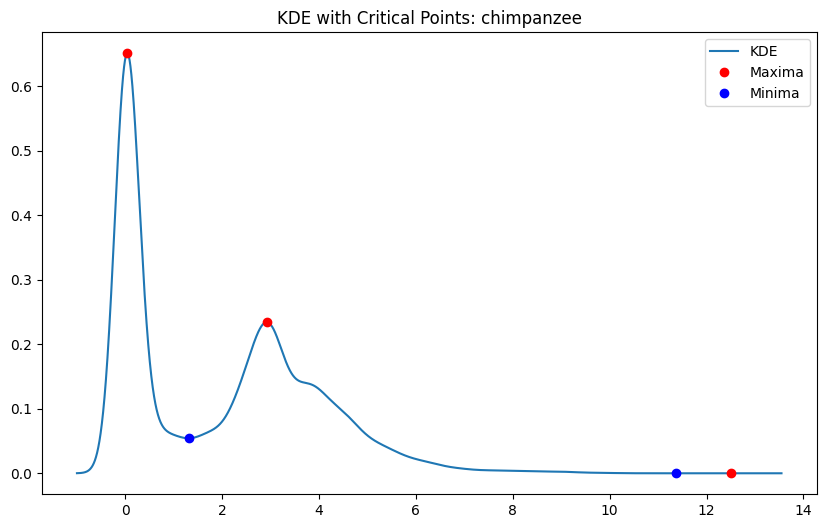

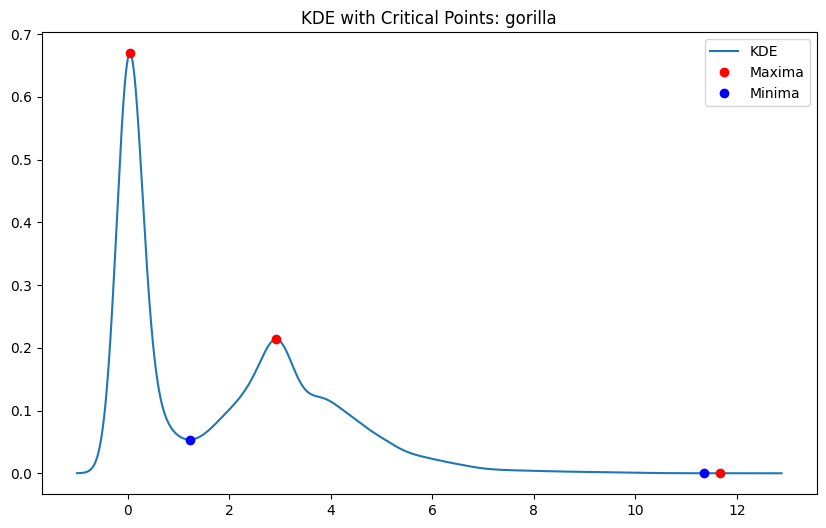

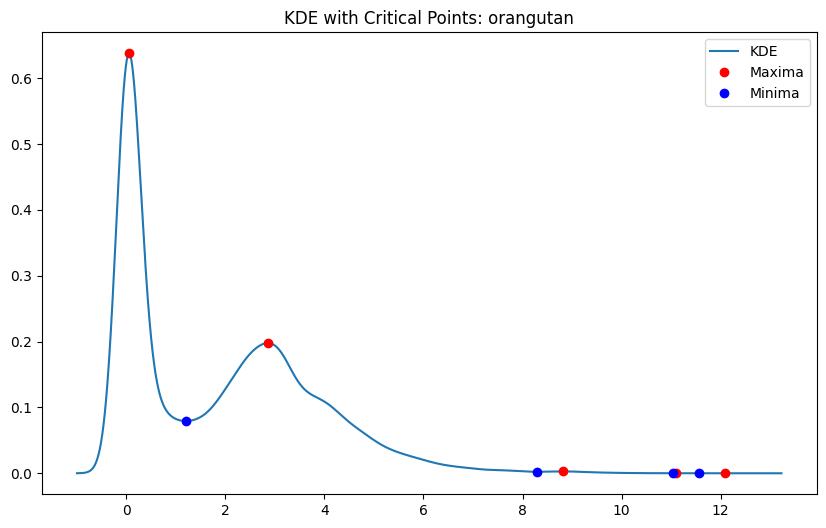

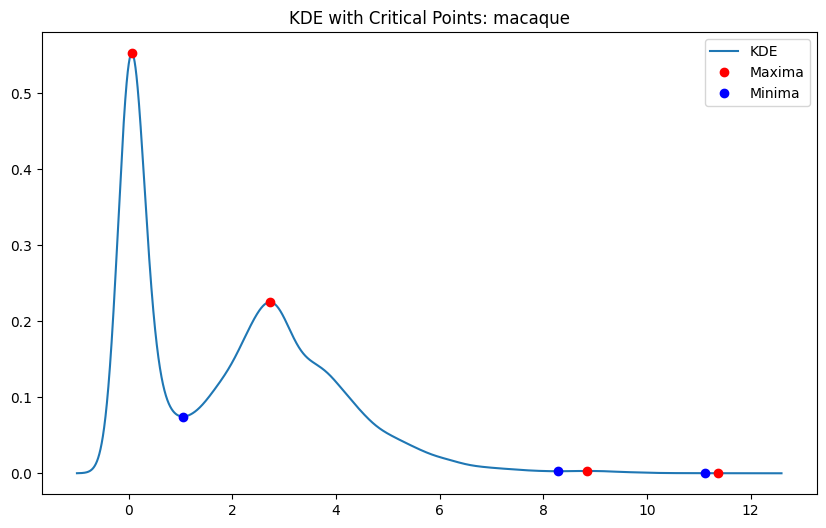

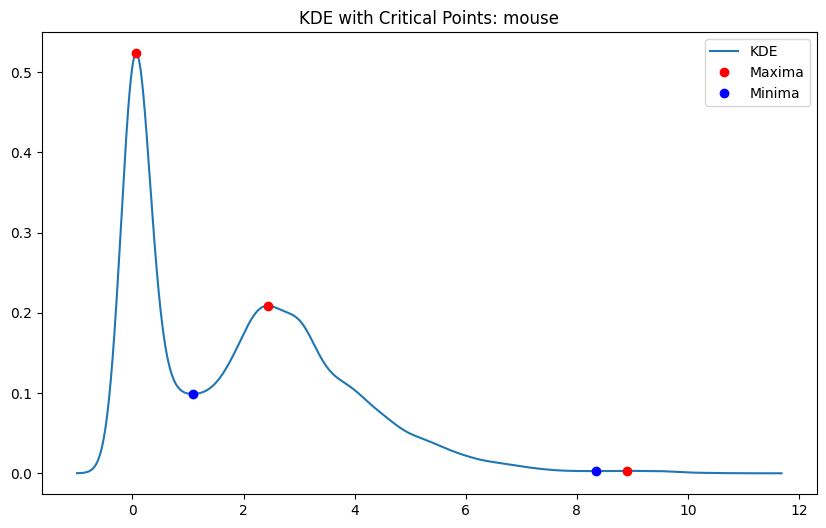

In [26]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.visualization()

spe_ot.visualization()

#### Check data size after preprocessing

Shape of adata after normalization and preprocessing
human (2895, 1144)
chimpanzee (839, 1083)
gorilla (3938, 1026)
orangutan (3367, 1107)
macaque (3798, 1129)
mouse (1236, 633)
# genes with all zero expression
human 0
chimpanzee 0
gorilla 0
orangutan 0
macaque 0
mouse 0


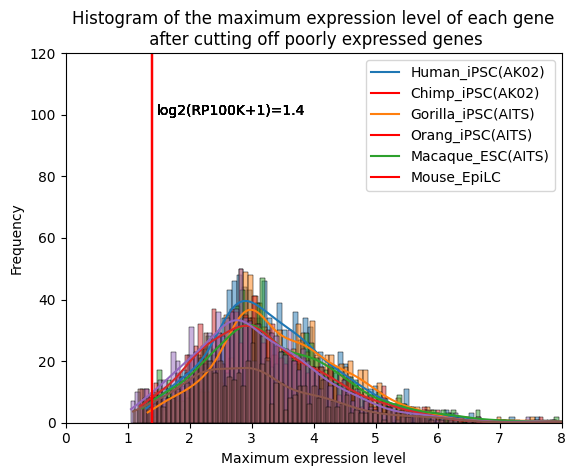

In [27]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.preprocessing(
# ).data_size_after_preprocessing()

spe_ot.data_size_after_preprocessing()

#### Plot which genes remained after preprocessing

In [28]:
labeled_genes = {}

for spe in spe_ot.species:
    labeled_genes[spe] = []
    
if spe_ot.data_option == "dataset1":
    labeled_genes["Ms"] = ["TBXT", "PRDM1", "PRDM14", "TFAP2C"]
    labeled_genes["Mf"] = ["GATA3", "GATA2", "EOMES", "SOX17", "TBXT",  "PRDM1", "PRDM14", "TFAP2C"]
    labeled_genes["Hs"] = ["GATA3", "GATA2", "EOMES", "SOX17", "PRDM1", "TFAP2C"]
elif spe_ot.data_option == "dataset2":
    for spe in spe_ot.species:
        labeled_genes[spe] = ["POU5F1", "SOX2", "NANOG"]

Explain Variance Ratio : [0.93988071 0.01751992]


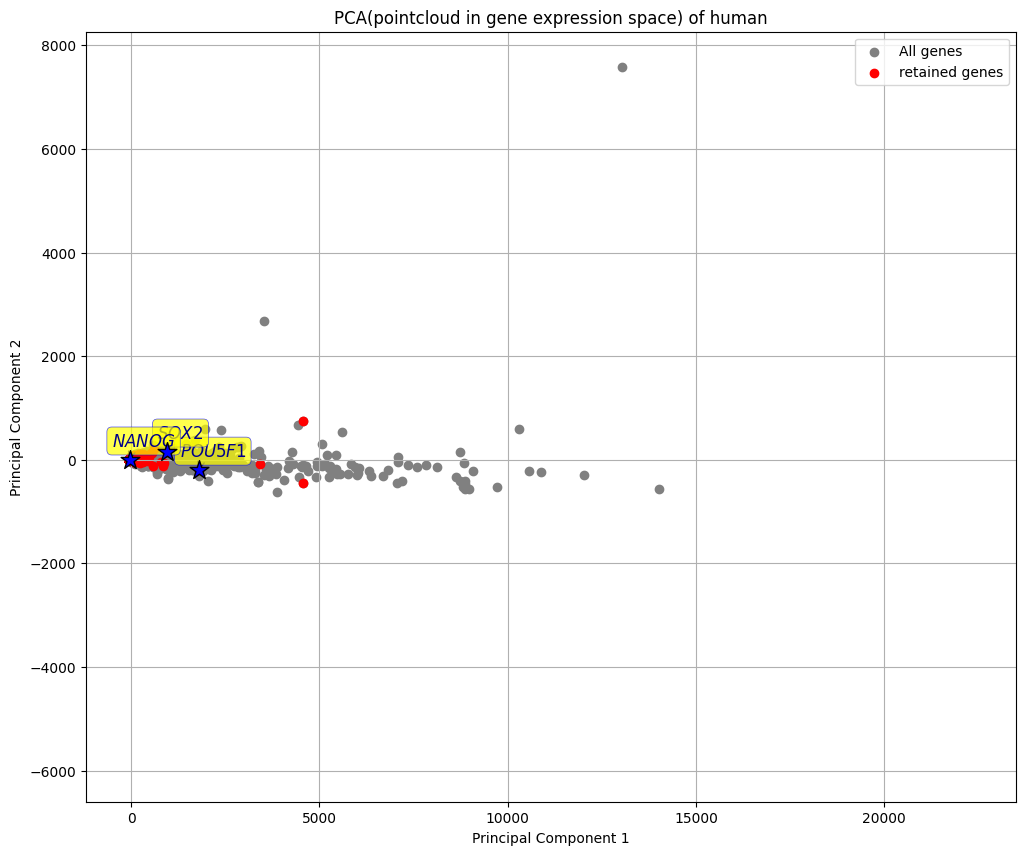

Explain Variance Ratio : [0.94923683 0.01515608]


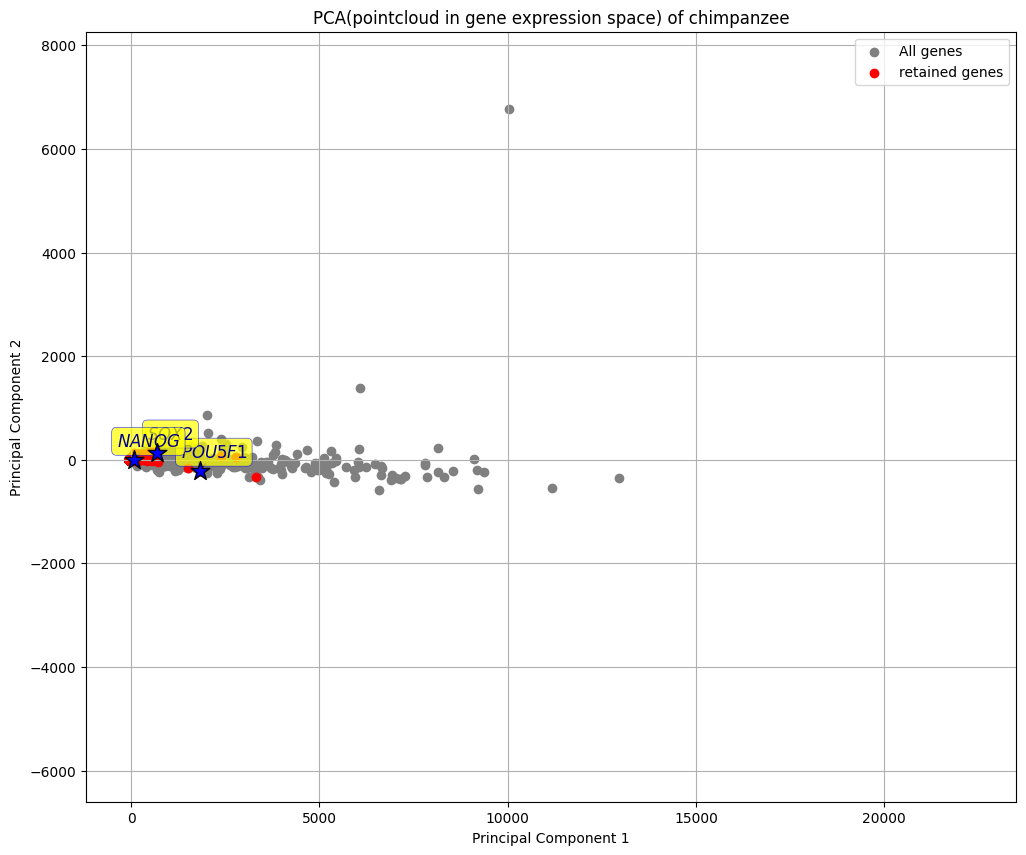

Explain Variance Ratio : [0.94500225 0.01021895]


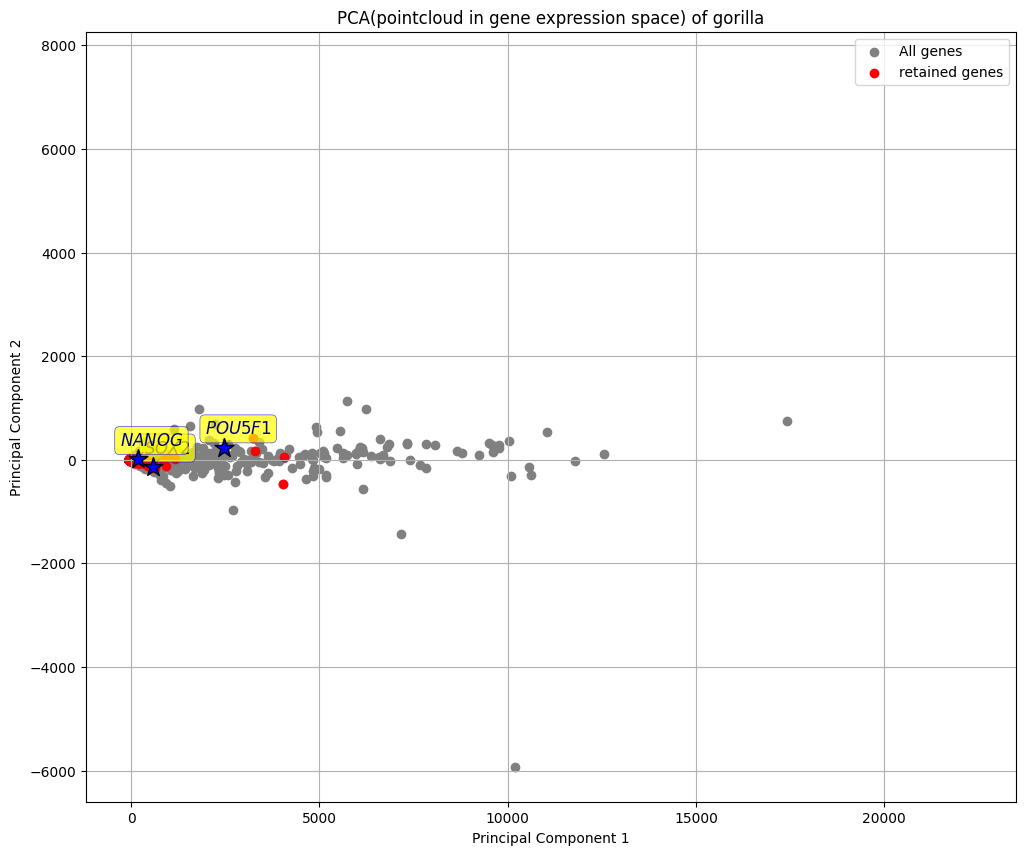

Explain Variance Ratio : [0.93471869 0.01127868]


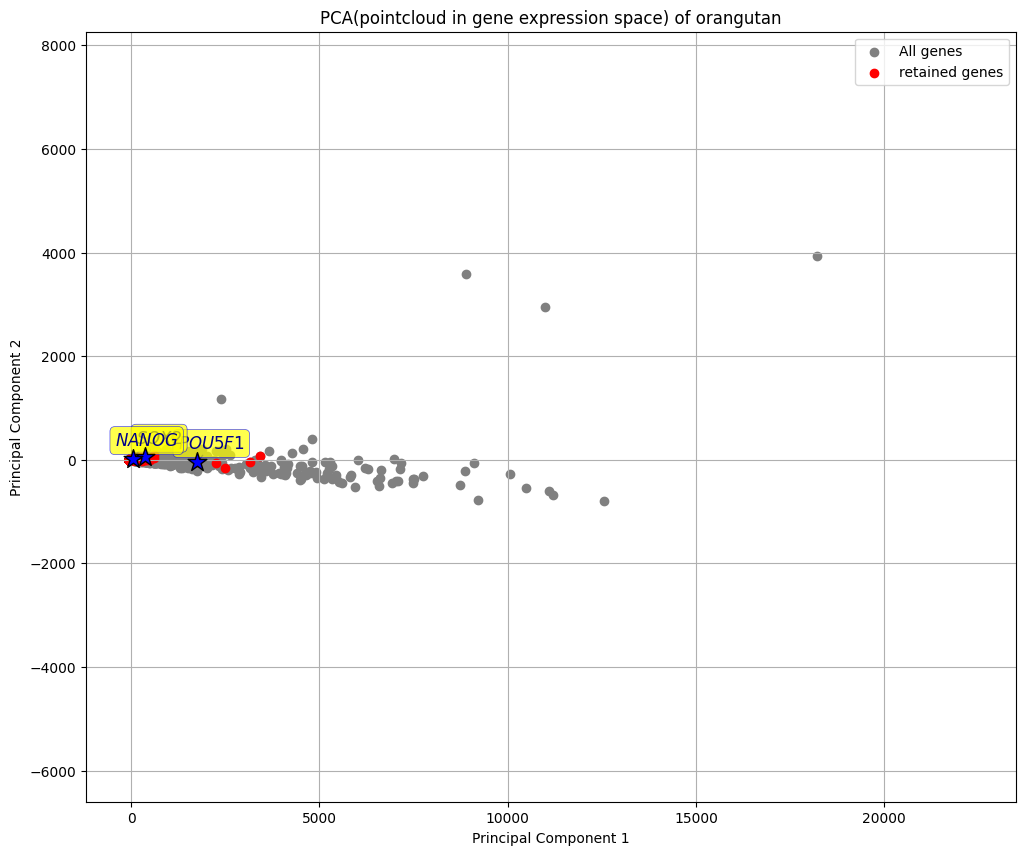

Explain Variance Ratio : [0.9528857  0.00984898]


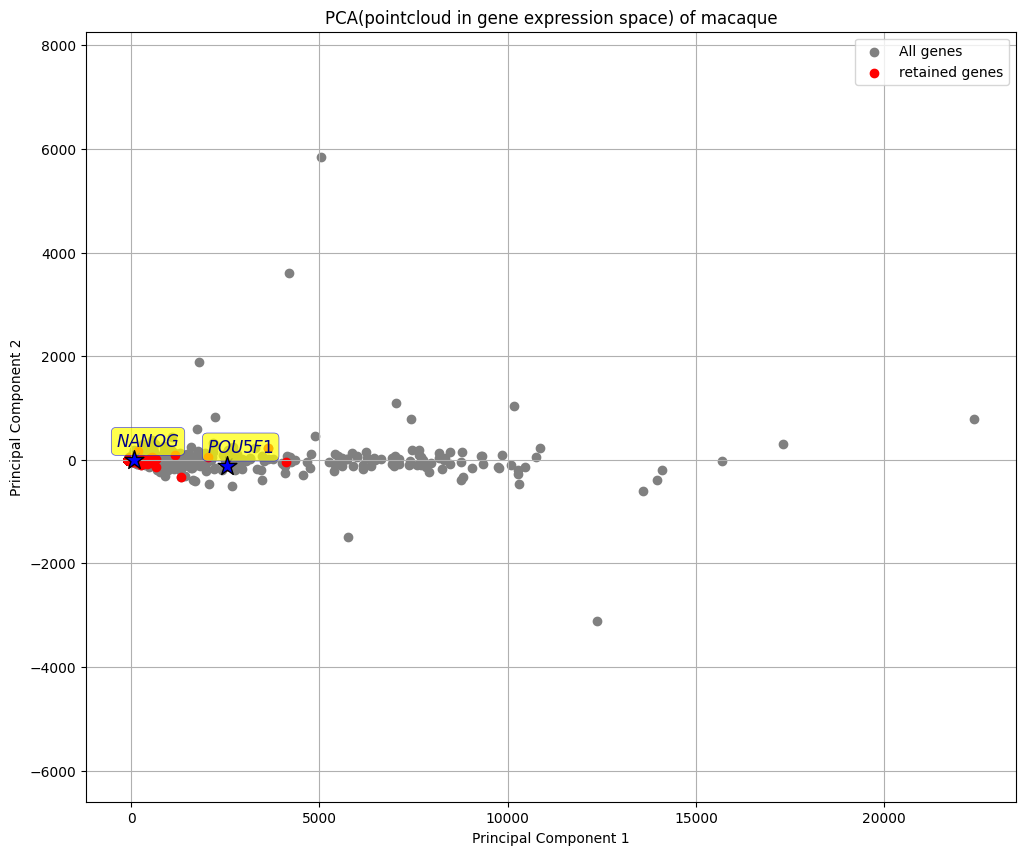

Explain Variance Ratio : [0.96340734 0.0041166 ]


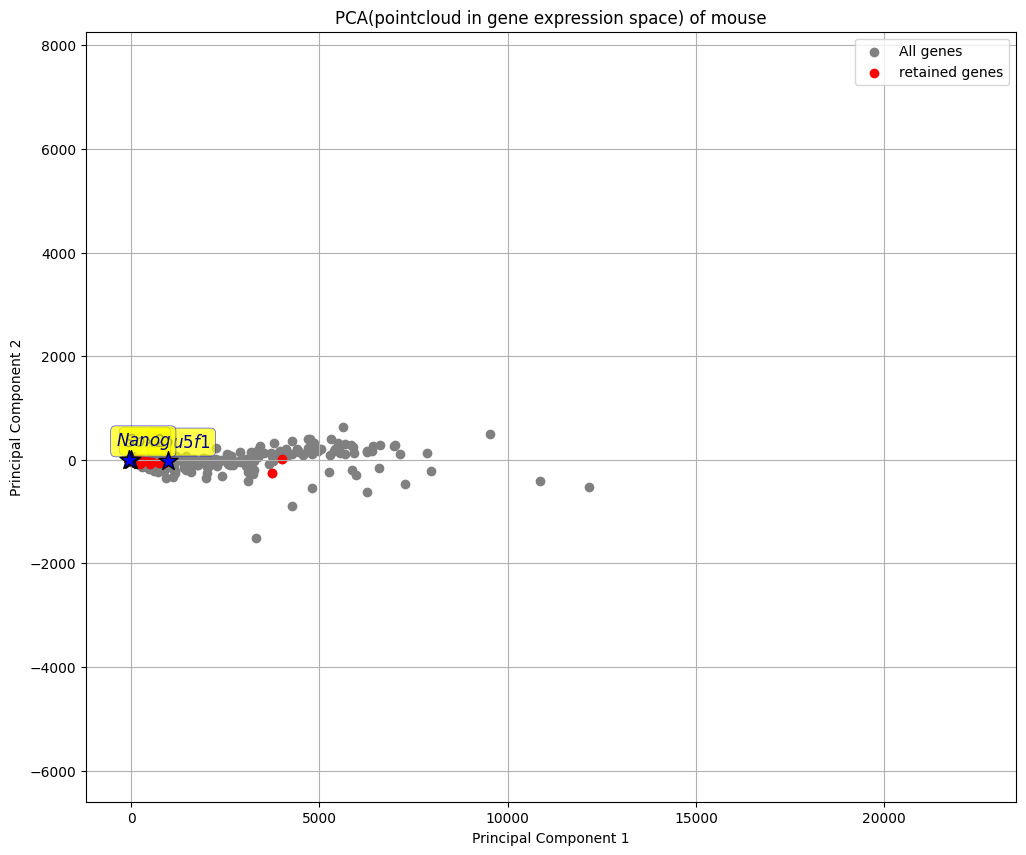

In [29]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.preprocessing(
# ).plot_pca_highlighting_genes_retained_after_preprocessing_plotly("all_gene", labeled_genes, spe_gene_dict)

spe_ot.plot_pca_highlighting_genes_retained_after_preprocessing("all_gene", labeled_genes, spe_gene_dict)

Visualization using Plotly is also possible (commented out for display purposes)

In [30]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.preprocessing(
# ).plot_pca_highlighting_genes_retained_after_preprocessing_plotly("all_gene", labeled_genes, spe_gene_dict)

# spe_ot.plot_pca_highlighting_genes_retained_after_preprocessing_plotly("all_gene", labeled_genes, spe_gene_dict)

#### Check calculated GW distance and OTP

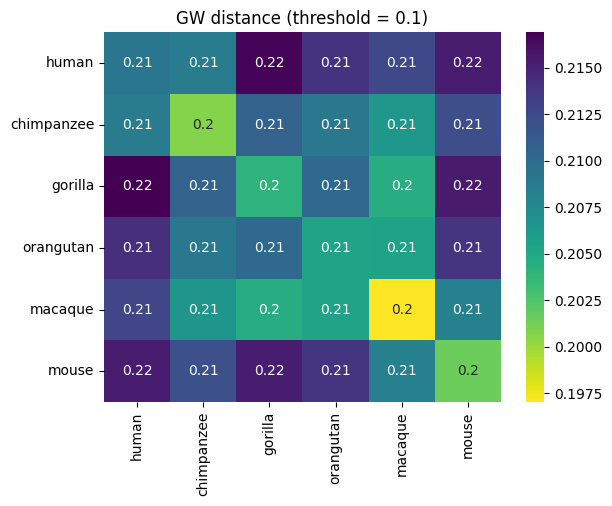

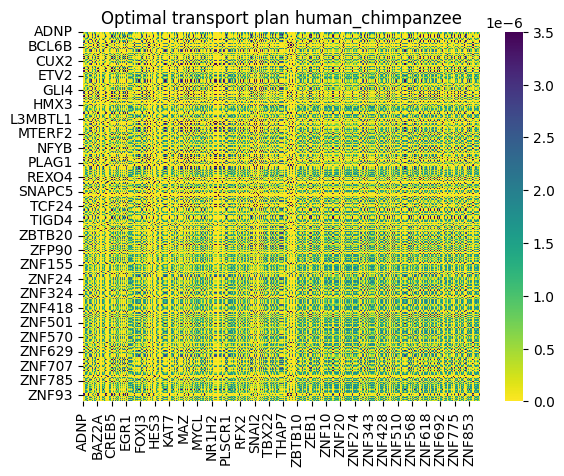

In [31]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.preprocessing(
# ).calculate_dismat(
# ).gromov_wasserstein_ot(
# ).check_optimal_transport_results()

spe_ot.check_optimal_transport_results()

#### Plot OTP after thresholding the top 5%

/Users/ytokuta/Species-OT/speciesot/speciesot.py:2764: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


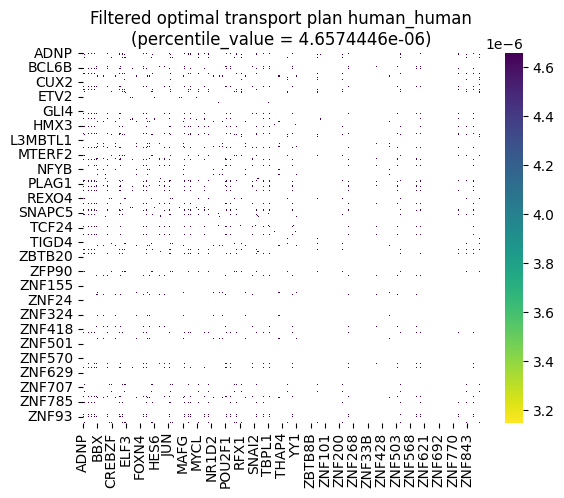

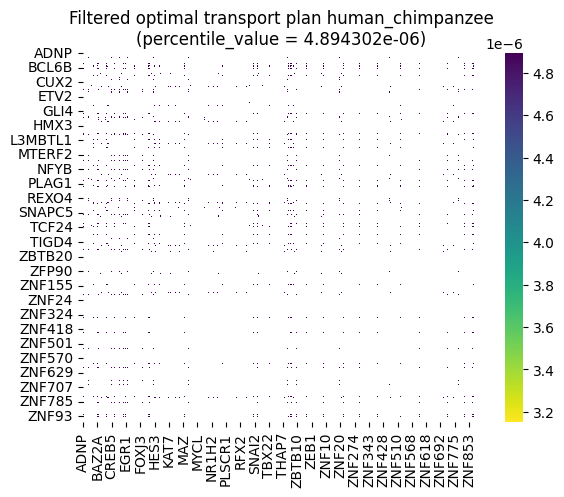

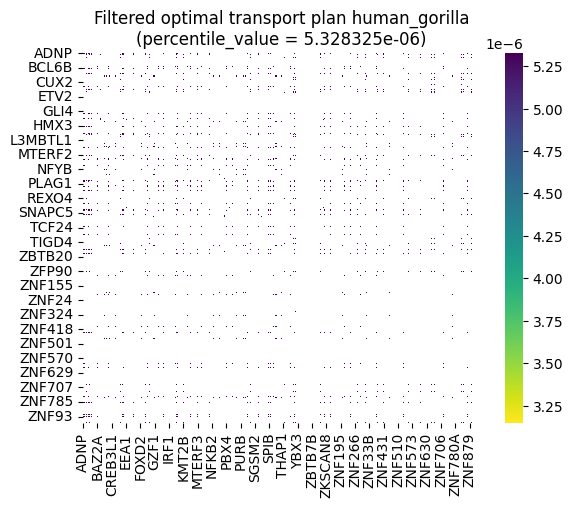

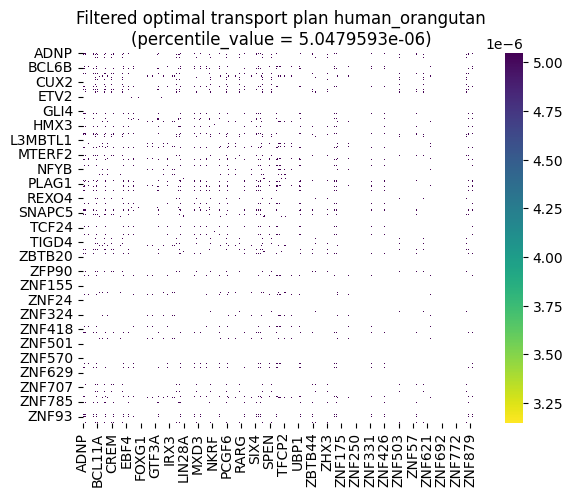

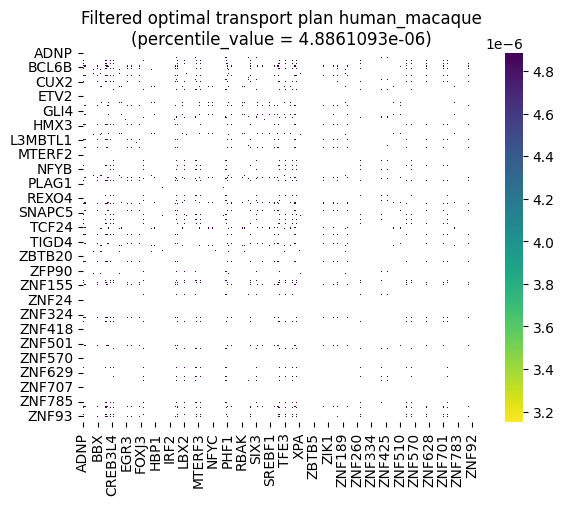

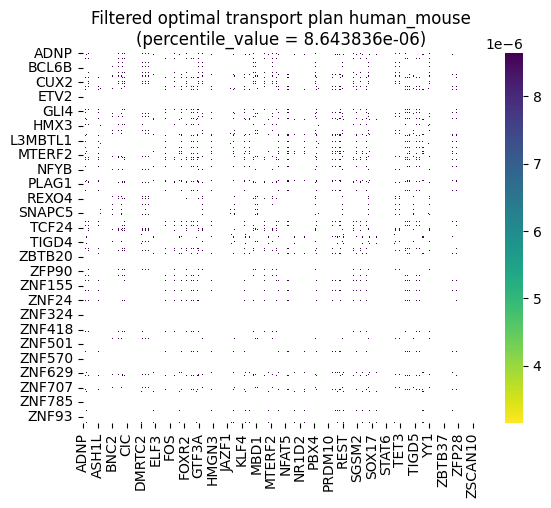

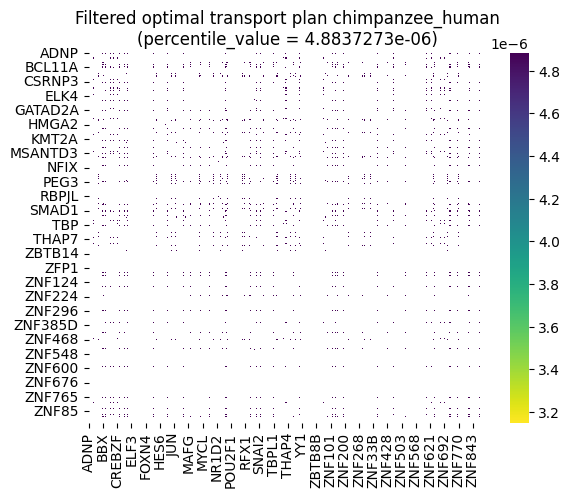

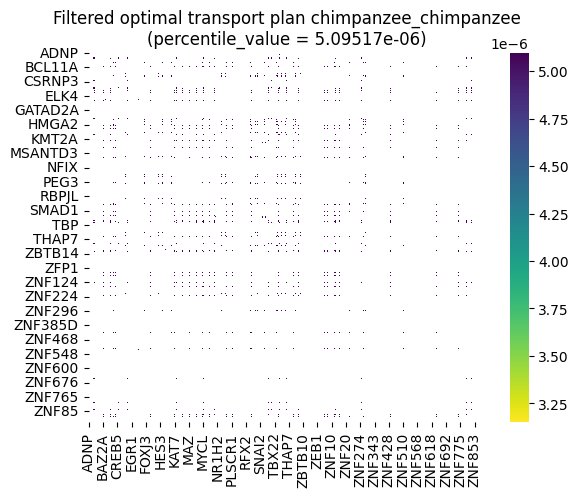

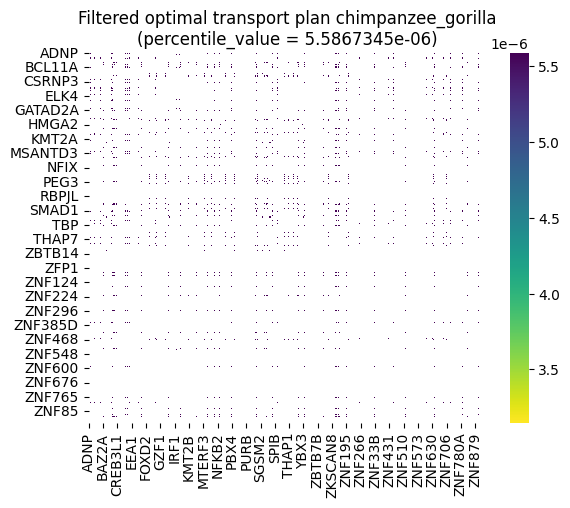

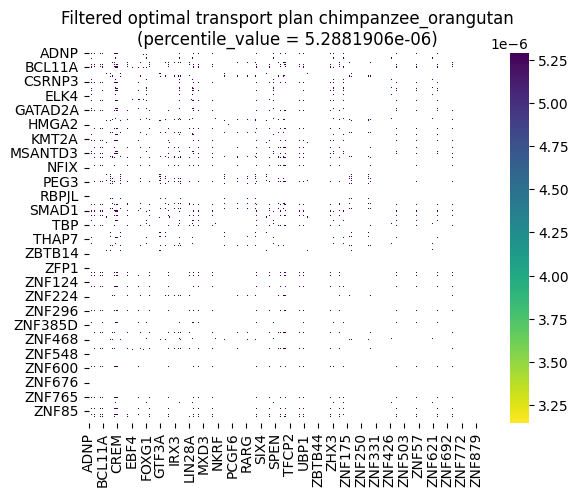

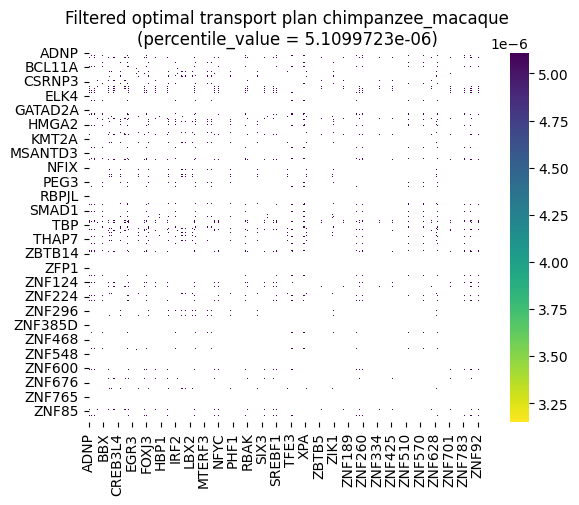

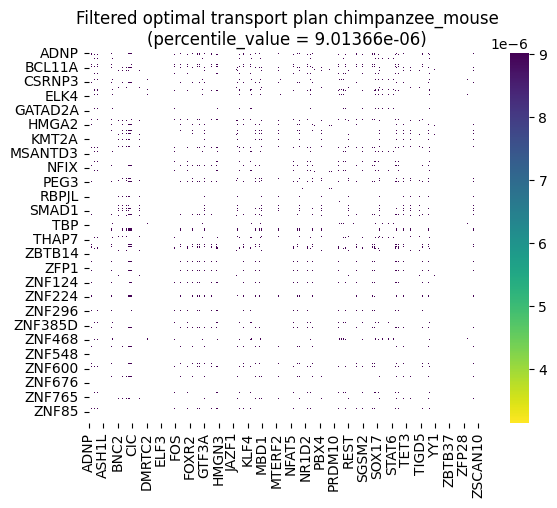

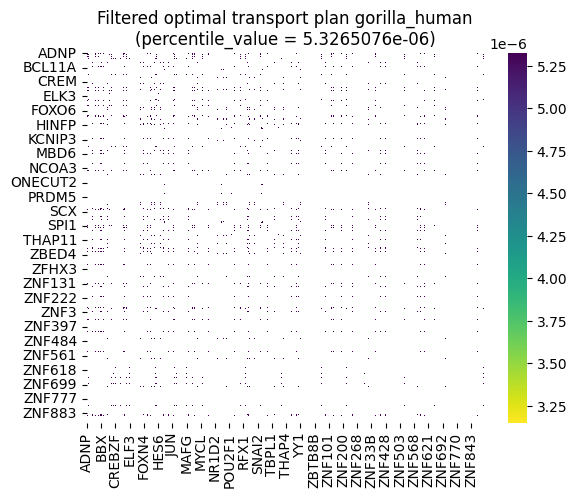

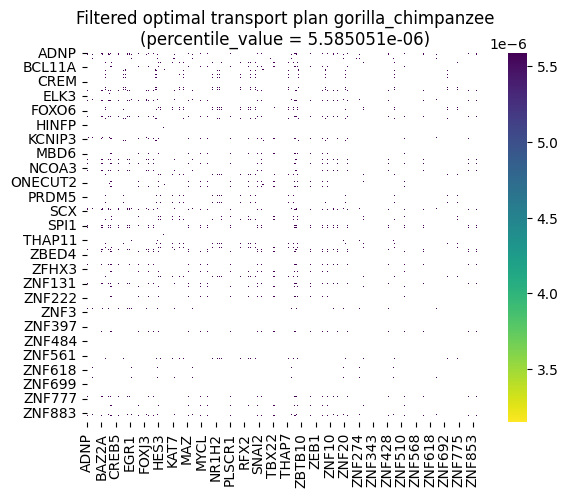

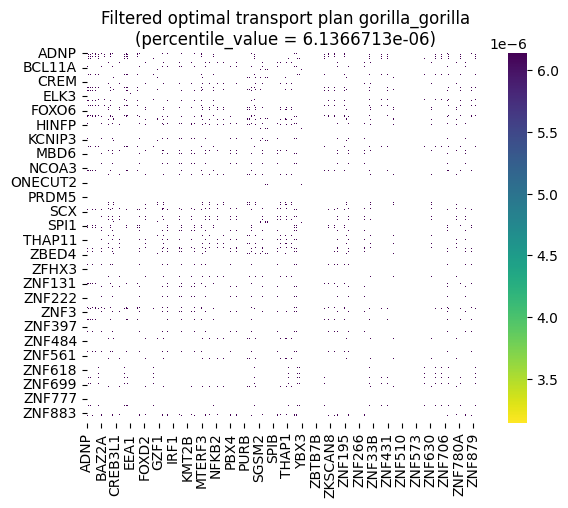

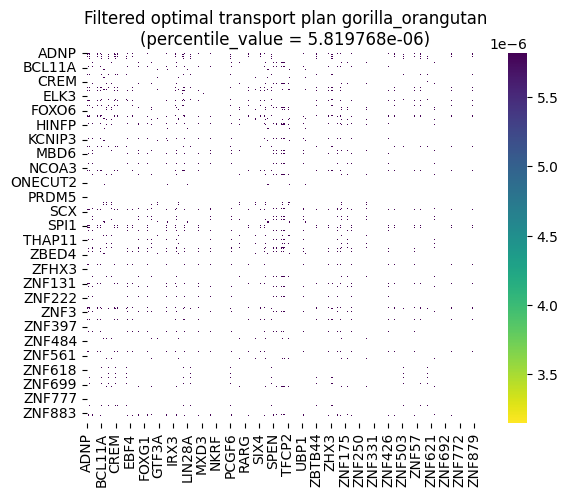

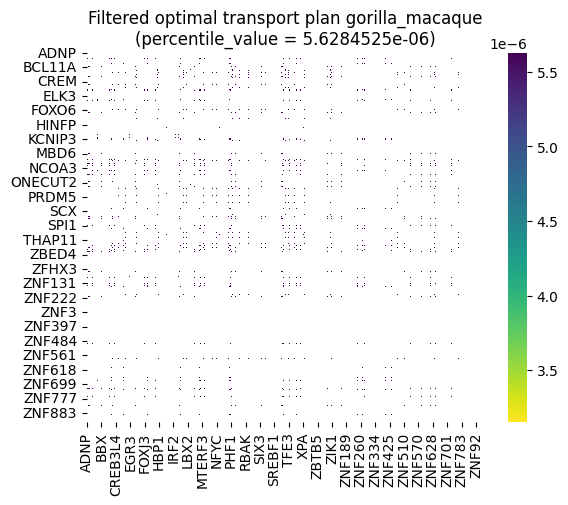

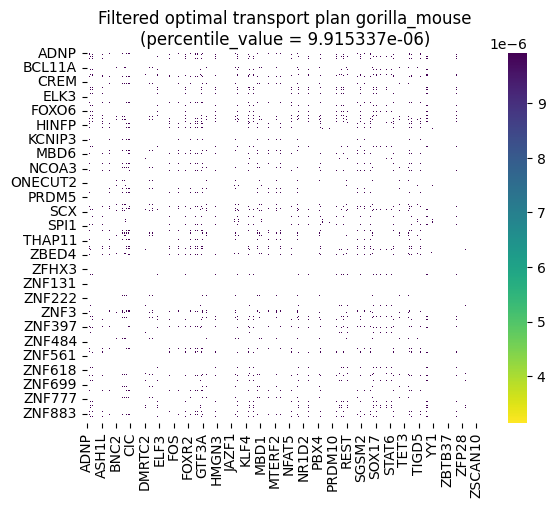

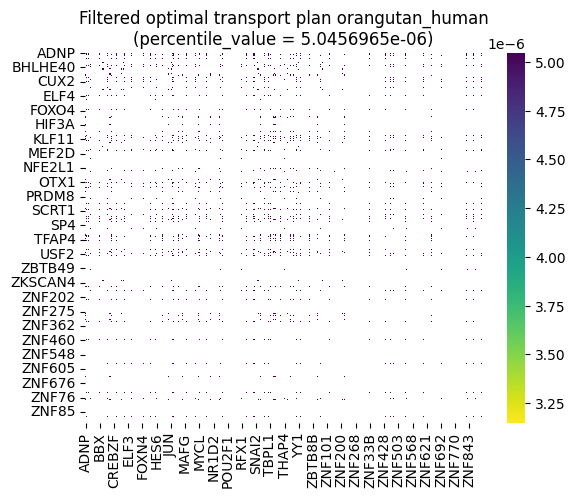

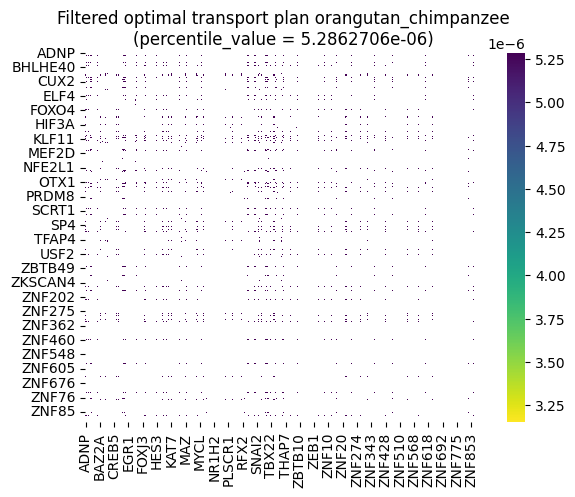

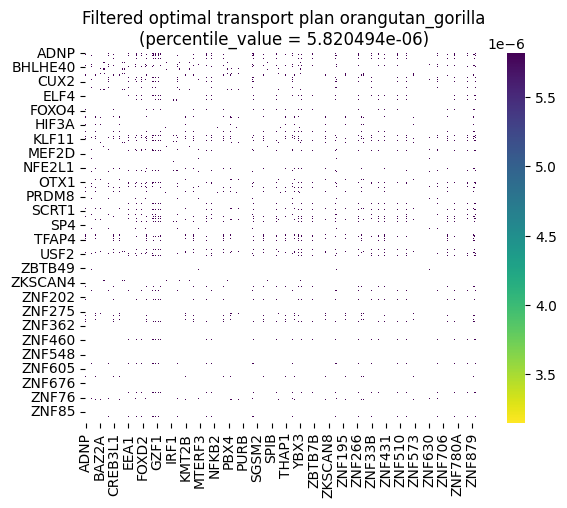

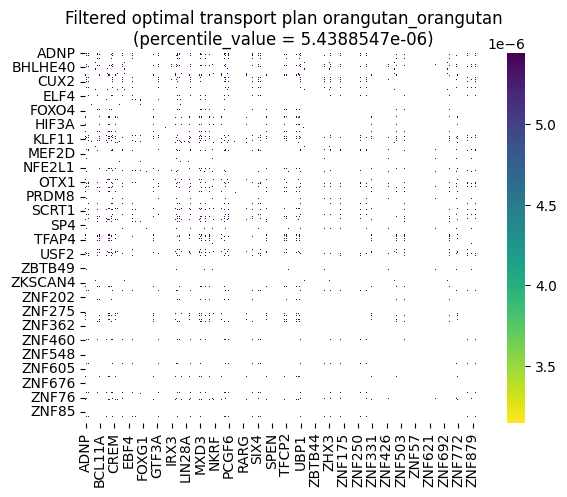

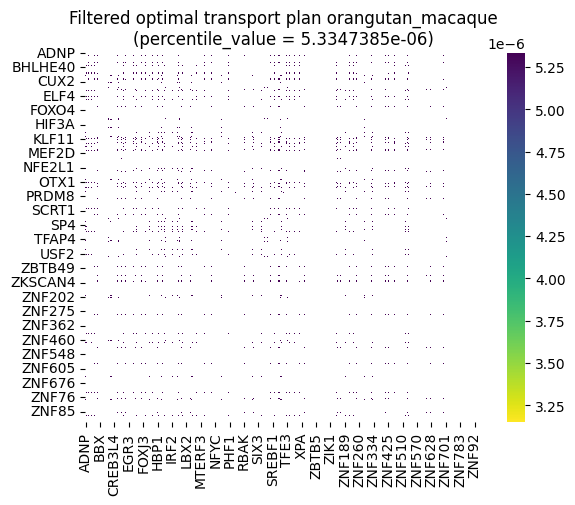

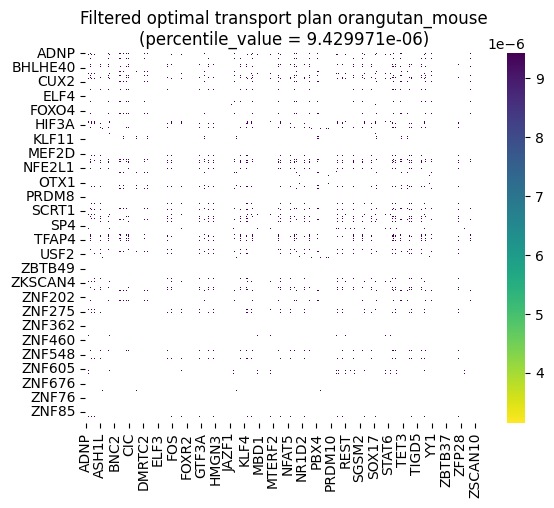

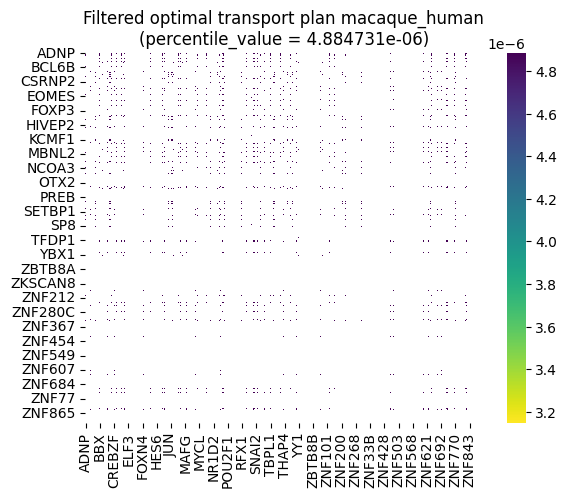

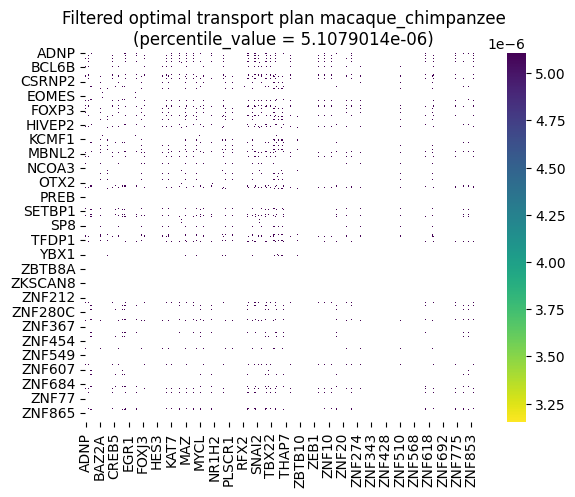

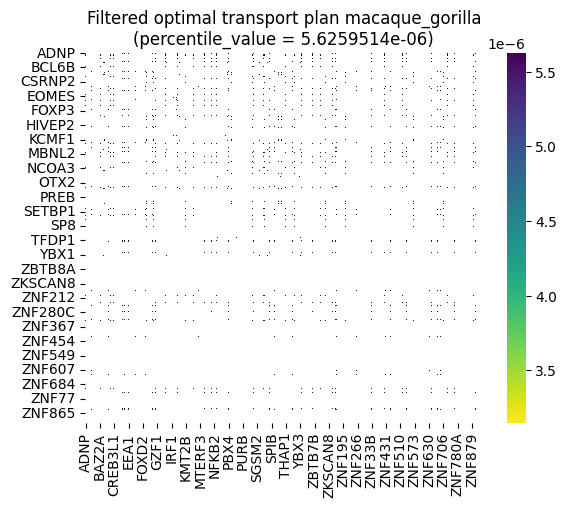

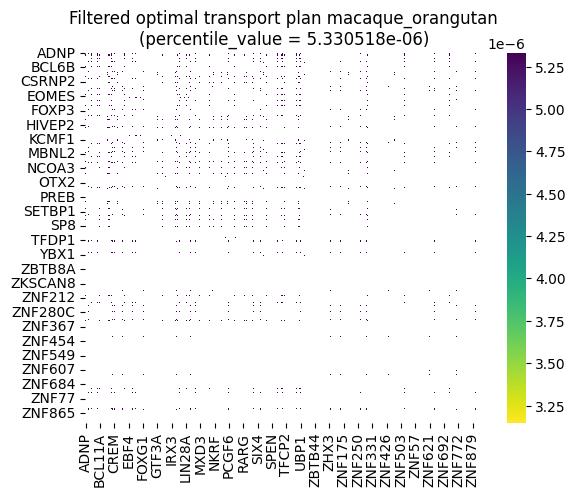

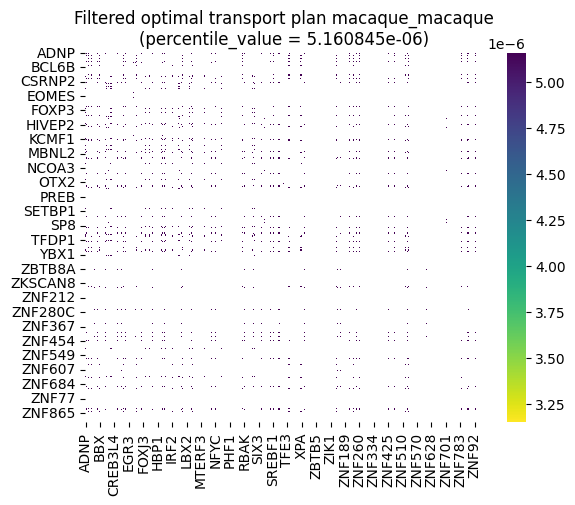

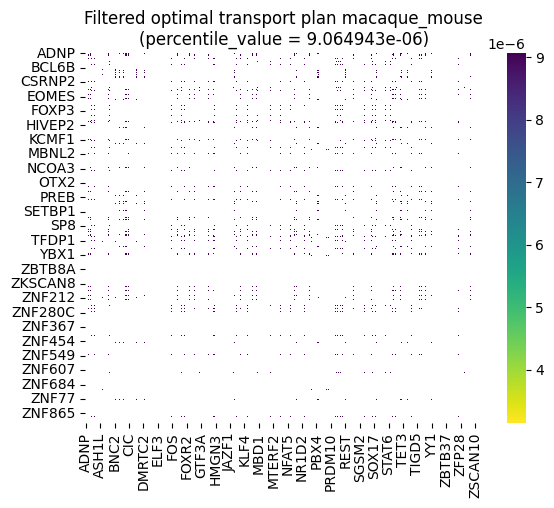

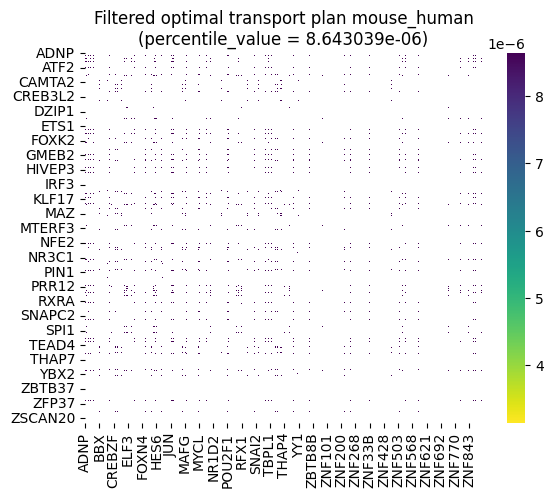

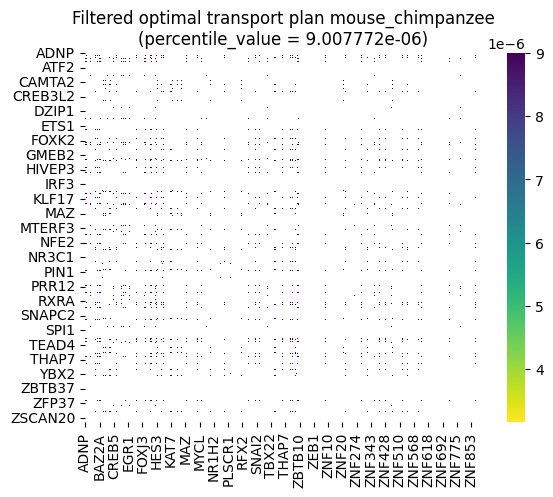

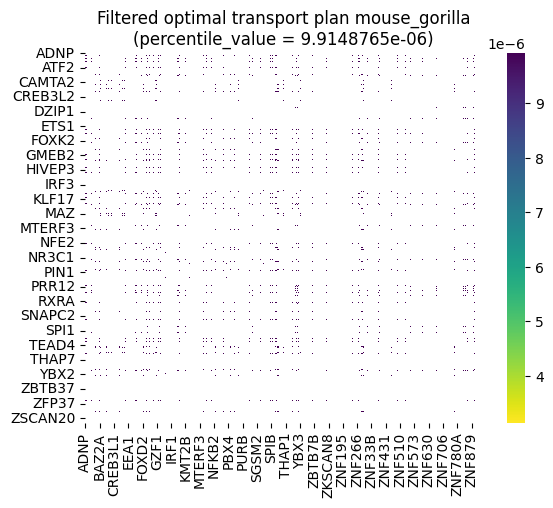

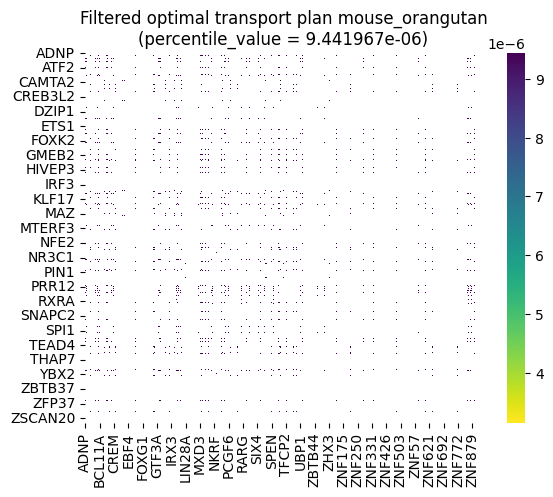

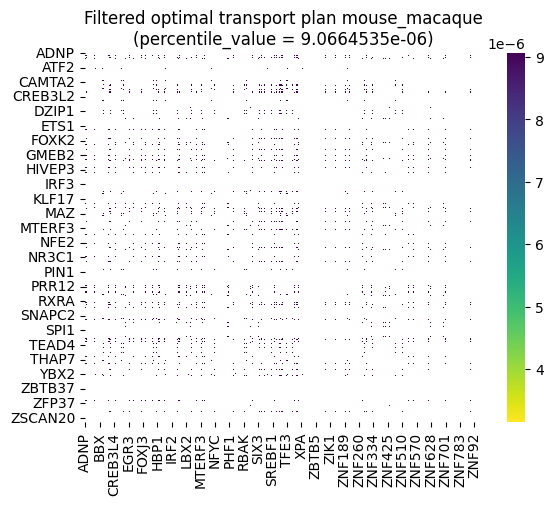

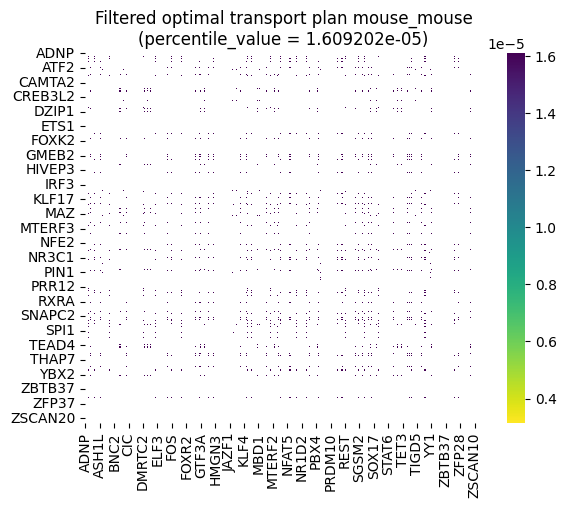

In [32]:
# spe_ot = SpeciesOT(Data)
# spe_ot.preprocessing(
# ).calculate_dismat(
# ).gromov_wasserstein_ot(
# ).filter_otp()

spe_ot.filter_otp()

#### Creat heatmap of common genes between species

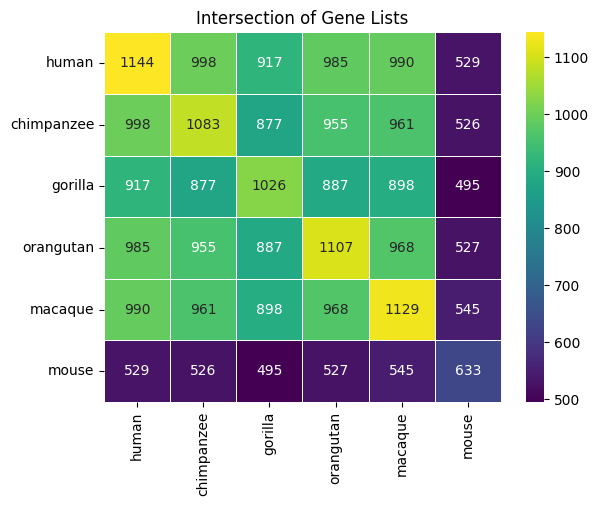

In [33]:
# spe_ot2 = SpeciesOT(Data)
# spe_ot2.preprocessing(
# ).calculate_dismat(
# ).gromov_wasserstein_ot(
# ).intersection_of_gene_lists()

spe_ot.intersection_of_gene_lists()

#### Check the distribution of the values of the normalized OTP

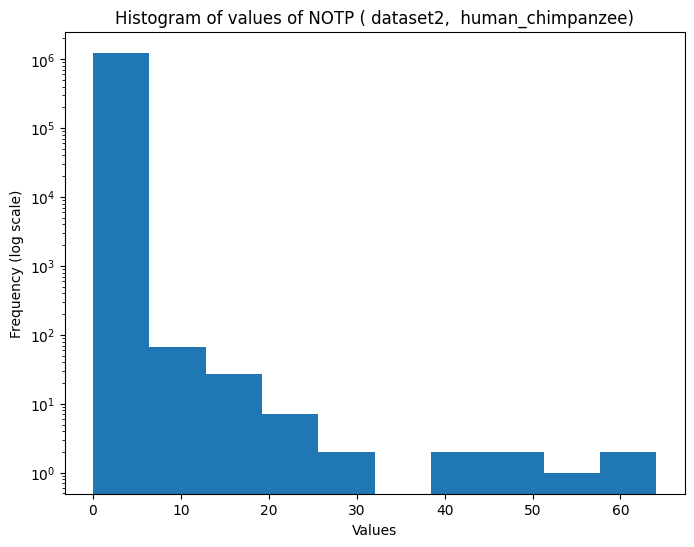

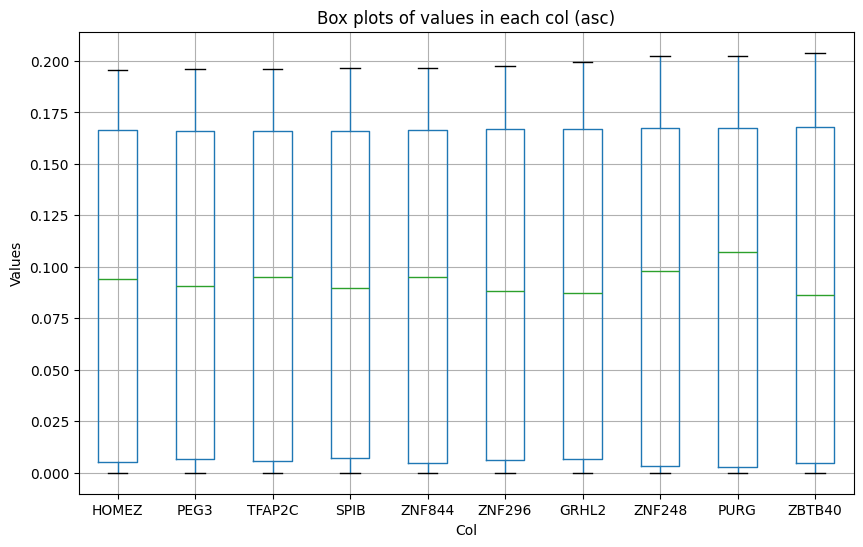

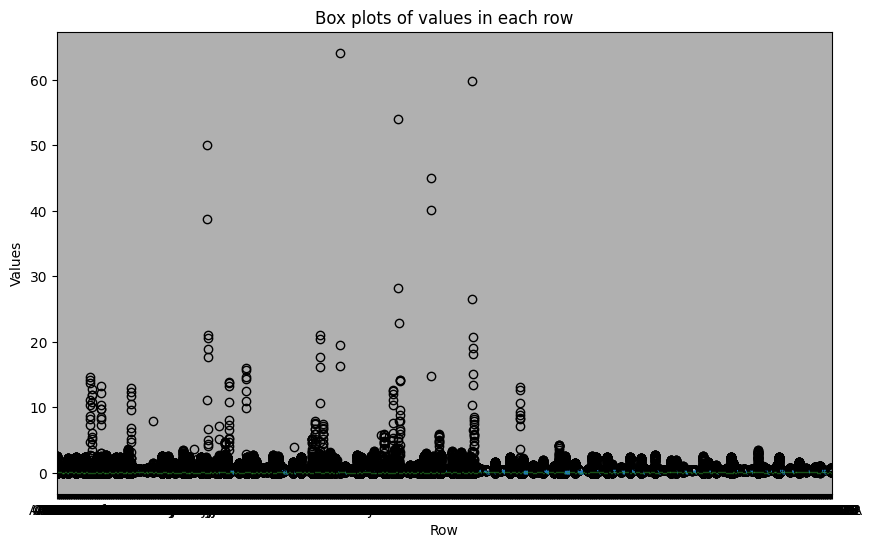

In [34]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.preprocessing(
# ).calculate_dismat(
# ).gromov_wasserstein_ot(
# ).normalize_otp(
# ).distribution_of_values()

spe_ot.distribution_of_values()

## Section 5. Chained Processing

In [35]:
data2 = Data(config).read_csv().normalization().read_tf()


human (2895, 32147)
chimpanzee (839, 28521)
gorilla (3938, 29854)
orangutan (3367, 28684)
macaque (3798, 25898)
mouse (1236, 21109)
# data size after noise reduction and normalization
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(16535), '#non-significant genes': np.int64(15612), '#silent genes': np.int64(0), 'ell': np.int64(65), 'Elapsed time': '0h 0m 8s 457ms', 'solver': 'full'}
human (2895, 32147)
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15569), '#non-significant genes': np.int64(12952), '#silent genes': np.int64(0), 'ell': np.int64(32), 'Elapsed time': '0h 0m 1s 687ms', 'solver': 'full'}
chimpanzee (839, 28521)
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(15118), '#non-significant genes': np.int64(14736), '#silent genes': np.int64(0), 'ell': np.int64(66), 'Elapsed time': '

In [37]:
spe_ot2 = SpeciesOT(data2).preprocessing(
).calculate_gene_distance_matrix(
).gromov_wasserstein_ot(
).normalize_otp(
).dashboard(
    target_species_pairs="human_chimpanzee", 
    target_genes=["POU5F1", "SOX2"], 
    top_n=10
    )

# Shape of gene expression data before masking
human (2895, 1492)
chimpanzee (839, 1431)
gorilla (3938, 1383)
orangutan (3367, 1449)
macaque (3798, 1443)
mouse (1236, 988)
# Shape of adata after removing columns (gene) where even the maximum value is below the threshold
human (2895, 1144)
chimpanzee (839, 1083)
gorilla (3938, 1026)
orangutan (3367, 1107)
macaque (3798, 1129)
mouse (1236, 633)
# Number of genes for which the maximum expression value is greater than a threshold value
human (1144,)
chimpanzee (1083,)
gorilla (1026,)
orangutan (1107,)
macaque (1129,)
mouse (633,)
epsilon = 0.1000000 converged
Human_iPSC(AK02) -> Chimp_iPSC(AK02): POU5F1Human_iPSC(AK02) -> Chimp_iPSC(AK02): SOX2
shape: (10, 3)                      shape: (10, 3)                      
┌───────┬────────┬─────────┐        ┌───────┬────────┬─────────┐        
│ index ┆ Gene   ┆ Value   │        │ index ┆ Gene   ┆ Value   │        
│ ---   ┆ ---    ┆ ---     │        │ ---   ┆ ---    ┆ ---     │        
│ u32   

## End